In [1]:
import statsmodels.api as sm
from analysis.trajectories import load_positions
from analysis.msd import compute_msd
from analysis.vacf import compute_velocity

import matplotlib.pyplot as plt

import numpy as np
from numpy.typing import NDArray

import scipy as sp



In [2]:
trajectories,*_ = load_positions('./output_droplet_tracking/csv_files/for_2.3_droplets.csv')


In [5]:
def compute_vacf(
    r: NDArray[np.floating],
    max_lag: int,
    dt: float = 1.0,
) -> NDArray[np.floating]:
    """
    Compute the velocity autocorrelation function for a single trajectory.
    Normalized VACF.
    Parameters
    ----------
    r : ndarray, shape (N, 2)
        Ordered (x, y) positions.
    dt : float
        Time step between consecutive frames.

    Returns
    -------
    vacf : ndarray, shape (N-1,)
        VACF values at lags τ = 0, 1, …, N-2 (in frame units).
        ``vacf[0] = <v·v>`` (mean kinetic energy per unit mass × 2).

    Notes
    -----
    Velocity is computed with ``compute_velocity`` (forward difference).
    The dot-product estimator is used:
    ``VACF(τ) = mean_t [vx(t)·vx(t+τ) + vy(t)·vy(t+τ)]``.
    """
    v = compute_velocity(r, dt)
    n = len(v)
    vacf = np.zeros(max_lag+1)
    for tau in range(maxlag+1):
        corr = v[:n - tau, 0] * v[tau:, 0] + v[:n - tau, 1] * v[tau:, 1]
        vacf[tau] = np.mean(corr)
    return vacf

In [6]:
# v = compute_velocity(trajectories[1],dt=0.2)
# maxlag = int(per*v.shape[0])

# vacf_sm = (
#     sm.tsa.acf(v[:,0], nlags=maxlag, fft=True)
#     +
#     sm.tsa.acf(v[:,1], nlags=maxlag, fft=True)
# )



for droplet ID - 1
mean_v - [-0.16402375 -0.0151377 ] 
rms_v - 1.2065731430554818 
drift_ratio - 0.1365195315448047


for droplet ID - 2
mean_v - [0.1392857  0.05400592] 
rms_v - 1.0110771405042531 
drift_ratio - 0.14775256725530467


for droplet ID - 5
mean_v - [ 0.00676061 -0.5403387 ] 
rms_v - 1.2069896246438339 
drift_ratio - 0.44770972653734903


for droplet ID - 6
mean_v - [-0.13212867 -0.42292064] 
rms_v - 1.053033365006007 
drift_ratio - 0.42076536516661156


for droplet ID - 7
mean_v - [ 0.32389175 -0.01951163] 
rms_v - 0.8870974613070491 
drift_ratio - 0.36577595147986747


for droplet ID - 8
mean_v - [0.11448534 0.09778751] 
rms_v - 1.0099776113400138 
drift_ratio - 0.14907582696560273



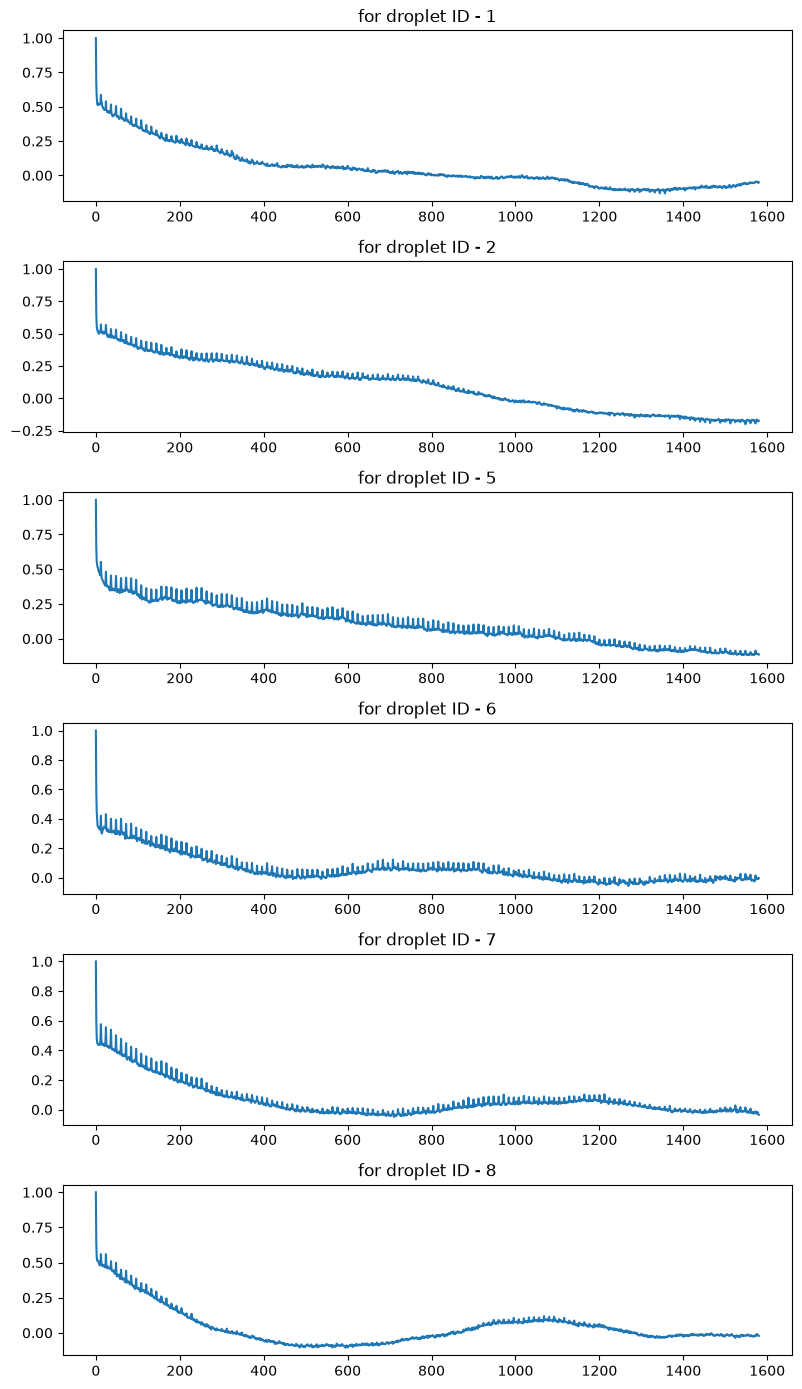

In [7]:
per = .4
fig, ax = plt.subplots(6, 1)
ax = ax.flatten()
fig.set_size_inches(8,14)
for idx, key in enumerate(trajectories.keys()):

    v = compute_velocity(trajectories[key], dt=0.2)
    maxlag = int(per*v.shape[0])
    
    mean_v = np.mean(v, axis=0)
    rms_v = np.sqrt(np.mean(v[:,0]**2 + v[:,1]**2))
    drift_ratio = np.linalg.norm(mean_v) / rms_v
    print(f'\nfor droplet ID - {key}')
    print(f'mean_v - {mean_v} \nrms_v - {rms_v} \ndrift_ratio - {drift_ratio}\n')

    vx = sm.tsa.acf(v[:, 0], nlags=maxlag, fft=True, adjusted=False)
    vy = sm.tsa.acf(v[:, 1], nlags=maxlag, fft=True, adjusted=False)

    vacf_sm = vx * np.mean(v[:, 0]**2) + vy * np.mean(v[:, 1]**2)
    # Normalize so that C(0)=1
    vacf_sm /= vacf_sm[0]

    tau = np.arange(vacf_sm.shape[0])
    ax[idx].plot(tau, vacf_sm)
    ax[idx].set_title(f'for droplet ID - {key}')


plt.tight_layout()


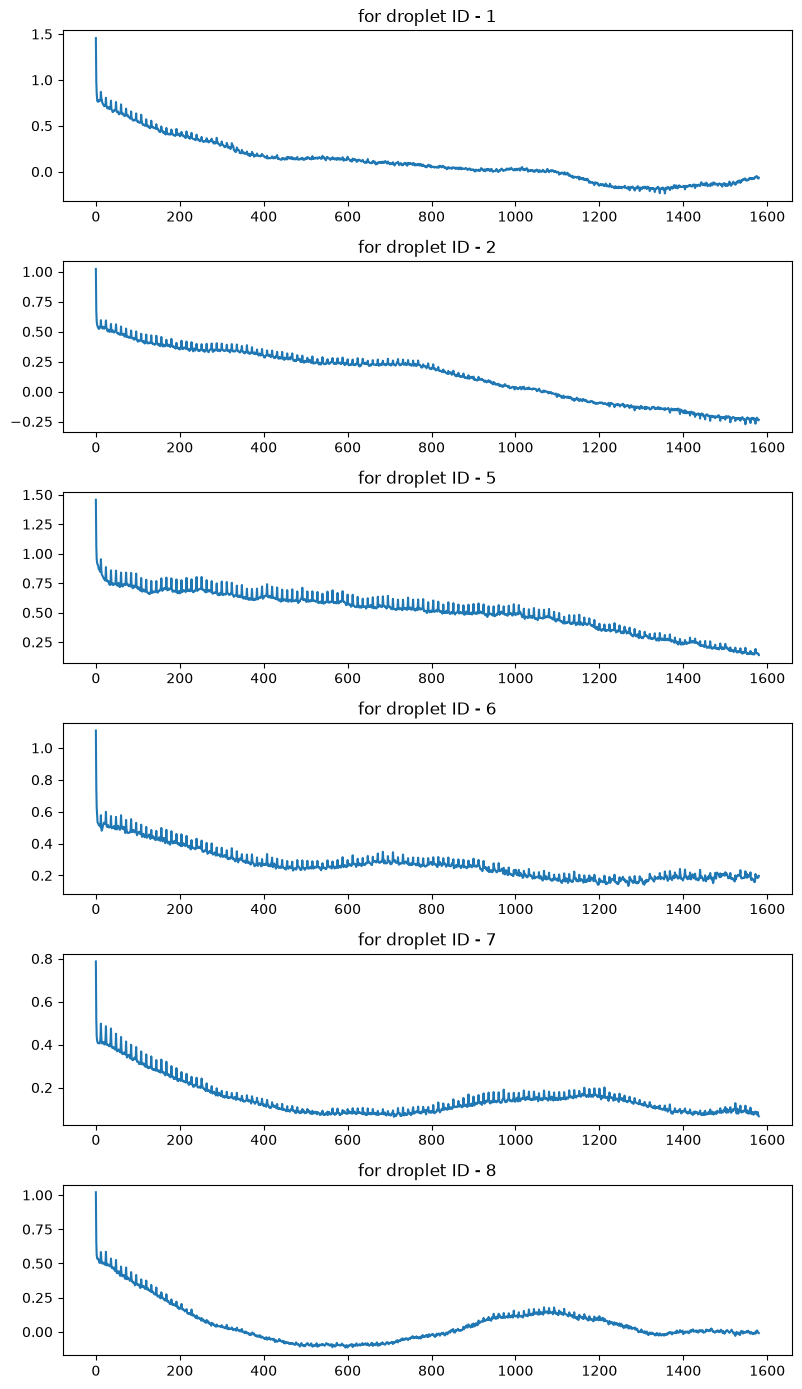

In [8]:
fig, ax = plt.subplots(6, 1)
ax = ax.flatten()
fig.set_size_inches(8,14)
for idx, key in enumerate(trajectories.keys()):

    
    vacf = compute_vacf(trajectories[key],max_lag=maxlag, dt=0.2)
    
    tau = np.arange(vacf.shape[0])

    ax[idx].plot(tau, vacf)
    ax[idx].set_title(f'for droplet ID - {key}')

plt.tight_layout()


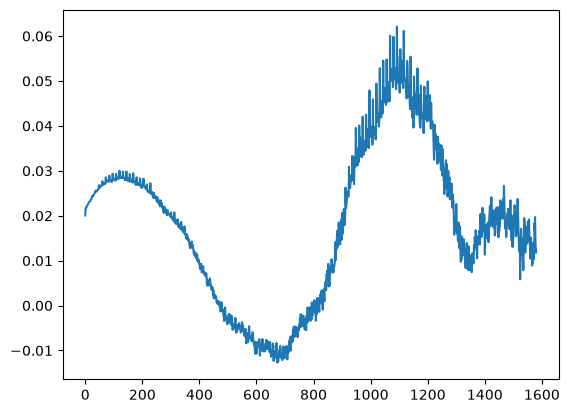

In [9]:

delta = vacf - vacf_sm
x = np.arange(0,delta.shape[0],1)
plt.plot(x,delta)



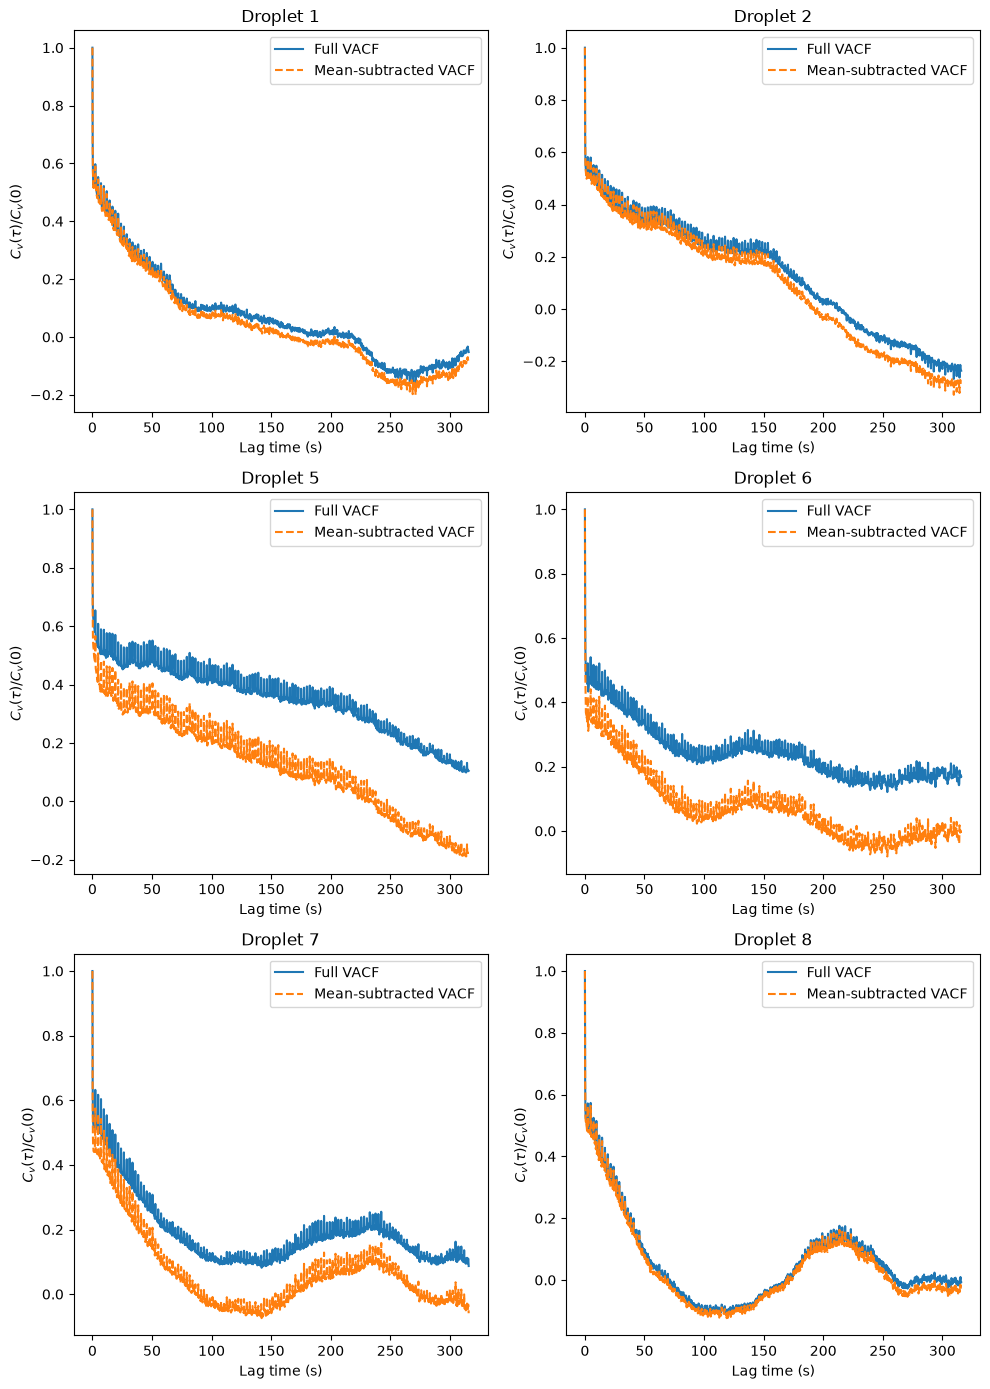

In [10]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 2, figsize=(10, 14))
ax = ax.flatten()

for idx, key in enumerate(trajectories.keys()):

    v = compute_velocity(trajectories[key], dt=0.2)

    # ----------------------------
    # Full VACF
    # ----------------------------
    vacf_full = compute_vacf(trajectories[key],max_lag=maxlag, dt=0.2)
    vacf_full /= vacf_full[0]

    # ----------------------------
    # Mean-subtracted VACF
    # ----------------------------
    v_centered = v - v.mean(axis=0)

    n = len(v_centered)
    vacf_centered = np.zeros(n)

    for tau in range(n):
        corr = (
            v_centered[:n - tau, 0] * v_centered[tau:, 0]
            +
            v_centered[:n - tau, 1] * v_centered[tau:, 1]
        )

        vacf_centered[tau] = np.mean(corr)

    vacf_centered /= vacf_centered[0]

    # ----------------------------
    # Plot
    # ----------------------------
    maxlag = int(0.4 * n)

    tau = np.arange(maxlag) * 0.2   # convert to seconds

    ax[idx].plot(
        tau,
        vacf_full[:maxlag],
        label="Full VACF"
    )

    ax[idx].plot(
        tau,
        vacf_centered[:maxlag],
        "--",
        label="Mean-subtracted VACF"
    )

    ax[idx].set_title(
        f"Droplet {key}"
    )

    ax[idx].set_xlabel("Lag time (s)")
    ax[idx].set_ylabel(r"$C_v(\tau)/C_v(0)$")

    ax[idx].legend()

plt.tight_layout()
plt.show()

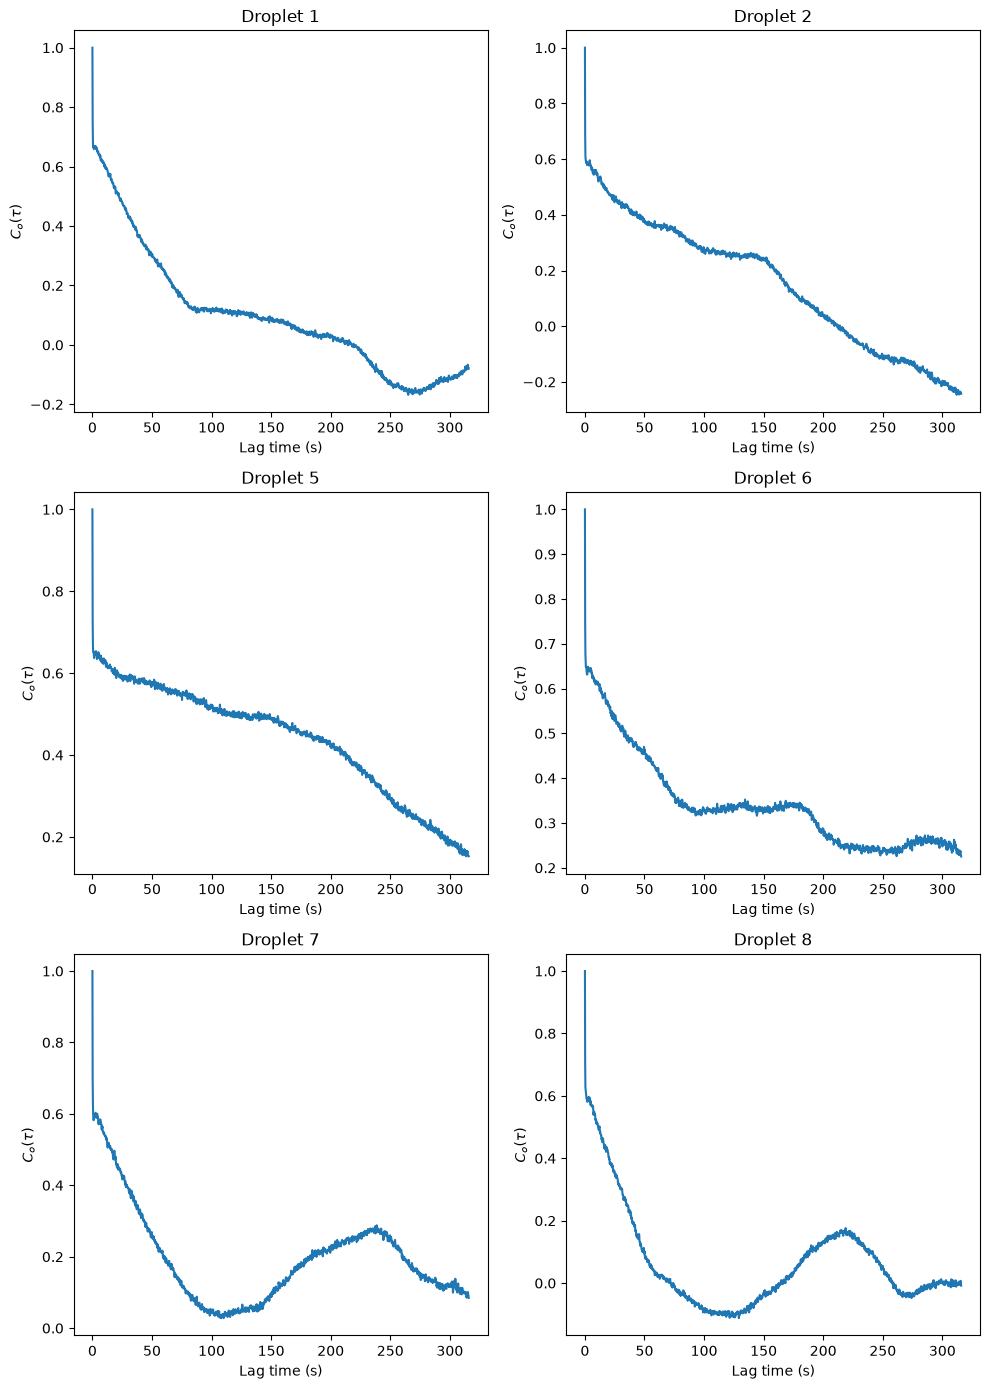

In [11]:
fig, ax = plt.subplots(3, 2, figsize=(10, 14))
ax = ax.flatten()

for idx, key in enumerate(trajectories.keys()):

    v = compute_velocity(trajectories[key], dt=0.2)

    # Unit orientation vectors
    speed = np.linalg.norm(v, axis=1)

    mask = speed > 0

    nvec = v[mask] / speed[mask, None]

    n = len(nvec)

    ocf = np.zeros(n)

    for tau in range(n):

        corr = (
            nvec[:n - tau, 0] * nvec[tau:, 0]
            +
            nvec[:n - tau, 1] * nvec[tau:, 1]
        )

        ocf[tau] = np.mean(corr)

    ocf /= ocf[0]

    maxlag = int(0.4 * n)

    tau = np.arange(maxlag) * 0.2

    ax[idx].plot(tau, ocf[:maxlag])

    ax[idx].set_title(f"Droplet {key}")

    ax[idx].set_xlabel("Lag time (s)")
    ax[idx].set_ylabel(r"$C_o(\tau)$")

plt.tight_layout()
plt.show()

Text(0, 0.5, 'PSD (arb. units)')

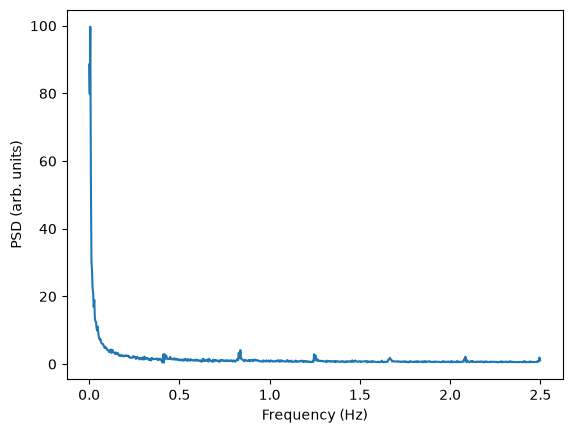

In [12]:
from scipy.fft import rfft, rfftfreq

dt = 0.2

Y = rfft(vacf)
freq = rfftfreq(len(vacf), d=dt)

plt.plot(freq, np.abs(Y))
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (arb. units)")

/tmp/ipykernel_2328/1623111385.py:21: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim((-.01e6,.09e6))


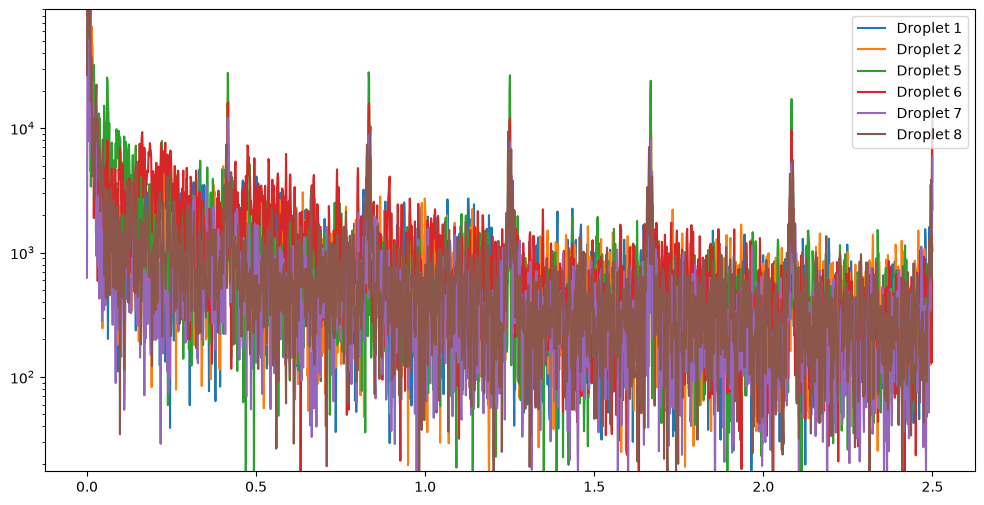

In [13]:
from scipy.signal import windows
figure, ax = plt.subplots(figsize=(12, 6))
for key in trajectories.keys():
    v = compute_velocity(trajectories[key], dt=0.2)

    vx = v[:,0] - np.mean(v[:,0])
    vy = v[:,1] - np.mean(v[:,1])

    window = windows.hann(len(vx))

    vxw = vx * window
    vyw = vy * window

    Sx = np.abs(rfft(vxw))**2
    Sy = np.abs(rfft(vyw))**2

    PSD = Sx + Sy
    freq = rfftfreq(len(vx), d=0.2)

    # plt.figure().set_size_inches(12,6)
    ax.set_ylim((-.01e6,.09e6))
    # ax.plot(freq, PSD, label=f'Droplet {key}')
    ax.semilogy(freq, PSD, label=f'Droplet {key}')
    
plt.legend()

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq

dt = 0.2

keys = list(trajectories.keys())

# Minimum common length
N = min(len(trajectories[k]) for k in keys)

# Stack trajectories
X = np.stack([trajectories[k][:N, 0] for k in keys])
Y = np.stack([trajectories[k][:N, 1] for k in keys])

# Ensemble mean trajectory
mean_x = X.mean(axis=0)
mean_y = Y.mean(axis=0)

# Remove mean position
mean_x -= mean_x.mean()
mean_y -= mean_y.mean()

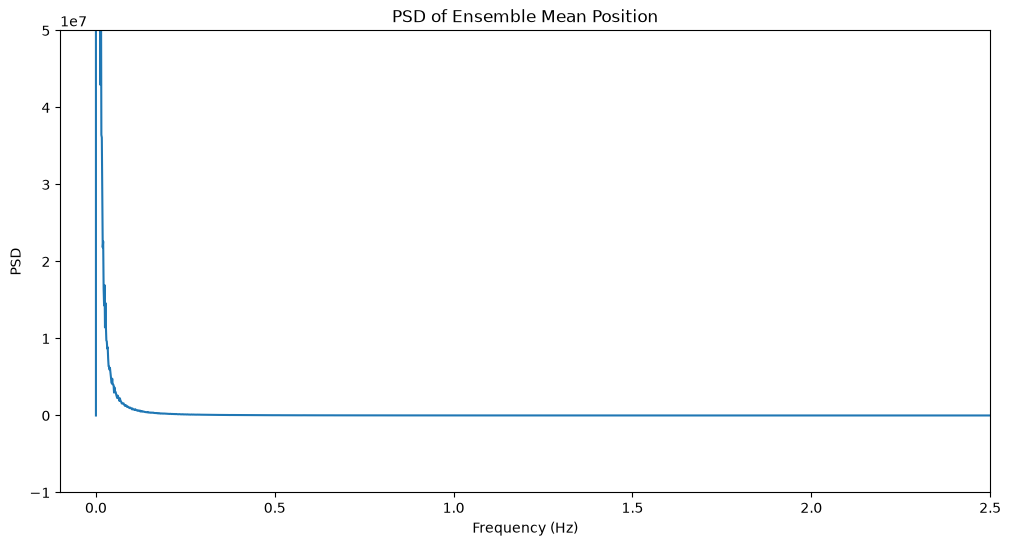

In [15]:
Sx = np.abs(rfft(mean_x))**2
Sy = np.abs(rfft(mean_y))**2

PSD_mean = Sx + Sy

freq = rfftfreq(N, d=dt)

plt.figure(figsize=(12, 6))
plt.plot(freq, PSD_mean)

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("PSD of Ensemble Mean Position")

plt.xlim(-.1, 2.5)
plt.ylim(-0.1e8, .05e9)
plt.show()

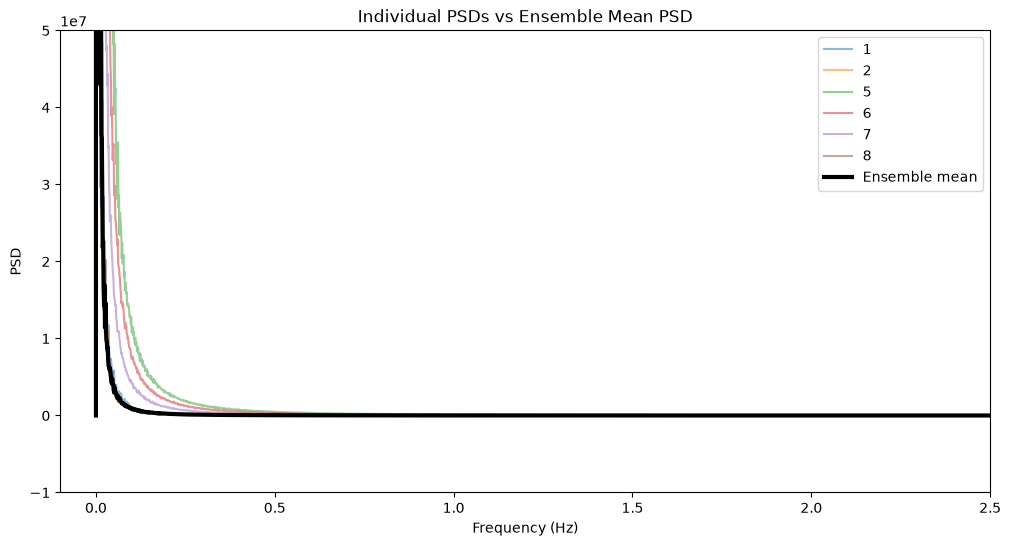

In [16]:
plt.figure(figsize=(12, 6))

for key in keys:

    r = trajectories[key][:N]

    x = r[:, 0] - np.mean(r[:, 0])
    y = r[:, 1] - np.mean(r[:, 1])

    PSD = np.abs(rfft(x))**2 + np.abs(rfft(y))**2

    plt.plot(freq, PSD, alpha=0.5, label=f"{key}")

plt.plot(
    freq,
    PSD_mean,
    color='k',
    linewidth=3,
    label='Ensemble mean'
)

plt.xlim(-.1, 2.5)
plt.ylim(-0.1e8, .05e9)



plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")

plt.legend()

plt.title("Individual PSDs vs Ensemble Mean PSD")

plt.show()

/tmp/ipykernel_2328/559671850.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


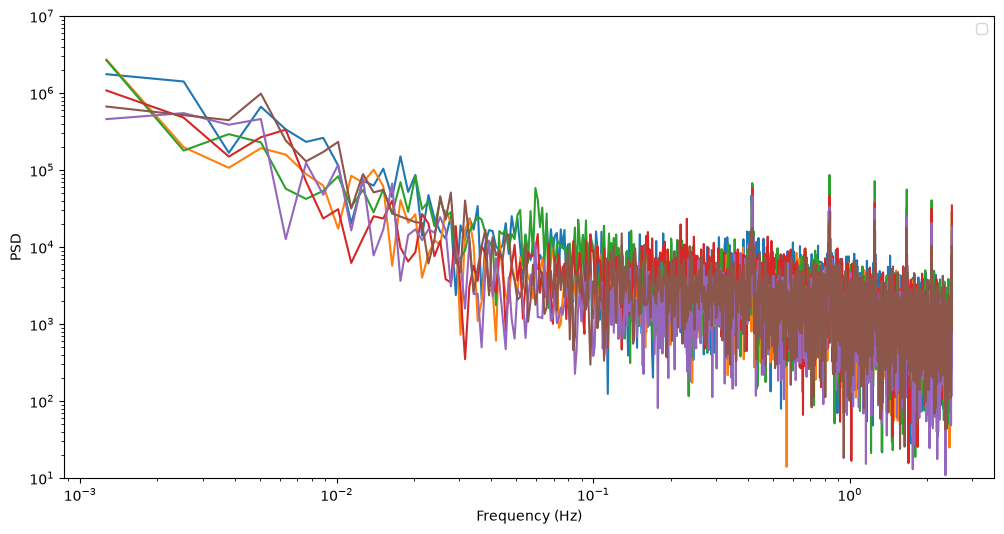

In [17]:
plt.figure(figsize=(12,6))

for key in keys:
    v = compute_velocity(trajectories[key], dt=0.2)

    vx = v[:,0] - np.mean(v[:,0])
    vy = v[:,1] - np.mean(v[:,1])

    PSD = np.abs(rfft(vx))**2 + np.abs(rfft(vy))**2

    # plt.semilogy(freq, PSD, alpha=0.7, label=f"{key}")
    plt.loglog(freq[1:], PSD[1:])
    # print(f"{freq[1:].shape} - {PSD[:].shape}\n")
# plt.xlim(0, 2.5)
plt.ylim(1e1, 1e7)

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.legend()
plt.show()

In [18]:

def compute_cross_vcaf(v1:NDArray[np.floating],
                    v2:NDArray[np.floating],
                    lag_time:int = int(trajectories[2].shape[0] * 0.4)):

    vi = compute_velocity(v1, dt=0.2)
    vj = compute_velocity(v2, dt=0.2)

    n = min(len(vi), len(vj))

    cij = np.zeros(lag_time)

    norm_i = np.mean(vi[:,0]**2 + vi[:,1]**2)
    norm_j = np.mean(vj[:,0]**2 + vj[:,1]**2)

    norm = np.sqrt(norm_i * norm_j)

    for tau in range(lag_time):

        corr = (
            vi[:n-tau,0] * vj[tau:,0]
            +
            vi[:n-tau,1] * vj[tau:,1]
        )

        cij[tau] = np.mean(corr) / norm
        
    return cij,lag_time

12
15
16
17
18
21
25
26
27
28
51
52
56
57
58
61
62
65
67
68
71
72
75
76
78
81
82
85
86
87


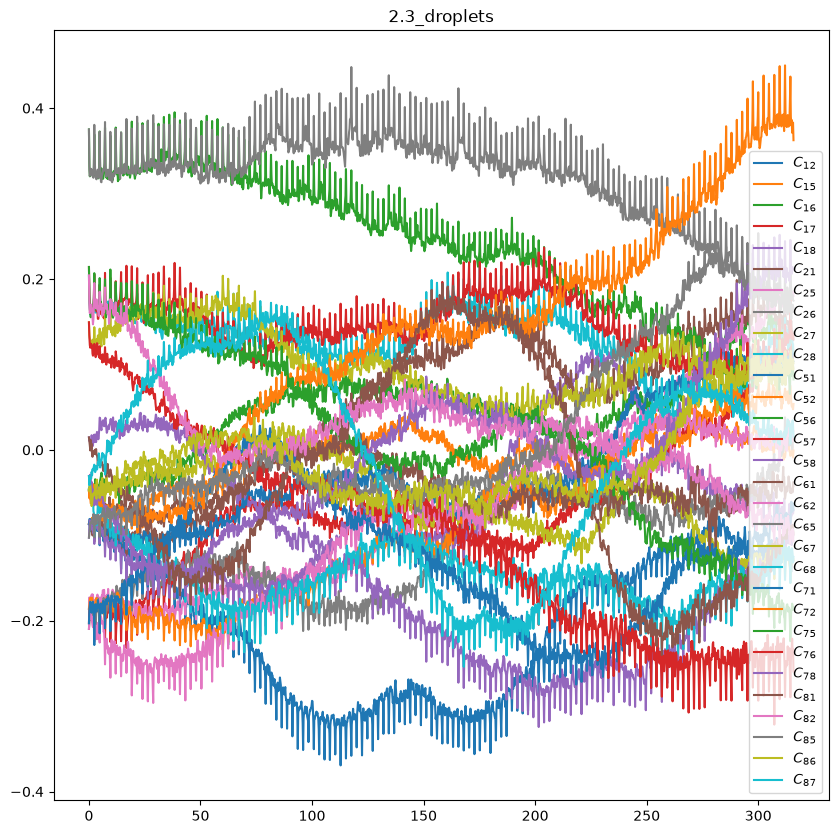

In [19]:
plt.figure().set_size_inches(10,10)

nsize = len(trajectories.keys())

m = np.zeros((nsize,nsize))

for i,key1 in enumerate(trajectories.keys()):
    for j,key2 in enumerate(trajectories.keys()):
        if key1 != key2:
            vi = trajectories[key1]
            vj = trajectories[key2]
            cij,lag_time = compute_cross_vcaf(v1 = vi,v2= vj)
            
            tau = np.arange(lag_time) * 0.2
            # plt.plot(tau,cij,label = f'droplet - id {key1} and droplet - id {key2}\n')
            lb = fr'{str(key1)+str(key2)}'
            print(lb)
            plt.plot(tau,cij,label = fr'$C_{str(key1)}$$_{str(key2)}$')
            
            plt.title('2.3_droplets')
            plt.legend()
            m[i,j] = cij[0]
    

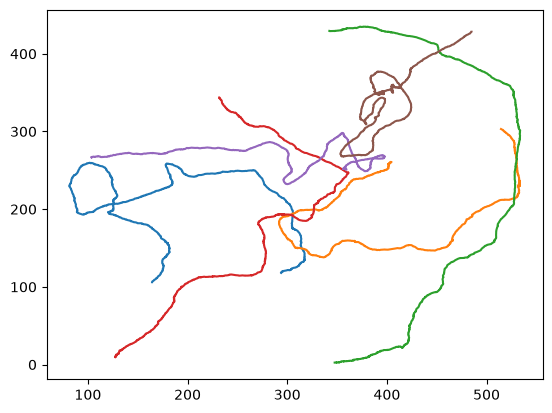

In [20]:
for key in keys:
    traj = trajectories[key]
    plt.plot(traj[:,0],traj[:,1])
    

In [21]:
m.shape

(6, 6)

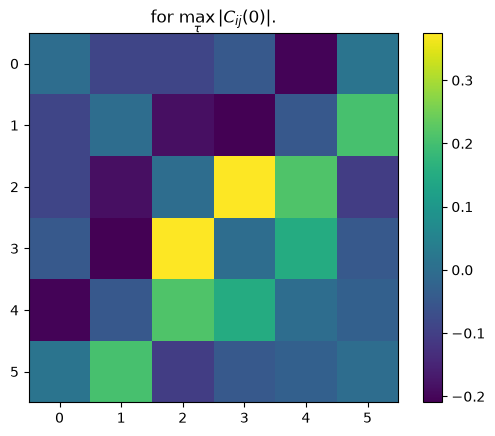

In [22]:
plt.imshow(m)
plt.title(r'for $\max_\tau |C_{ij}(0)|$.')
plt.colorbar()

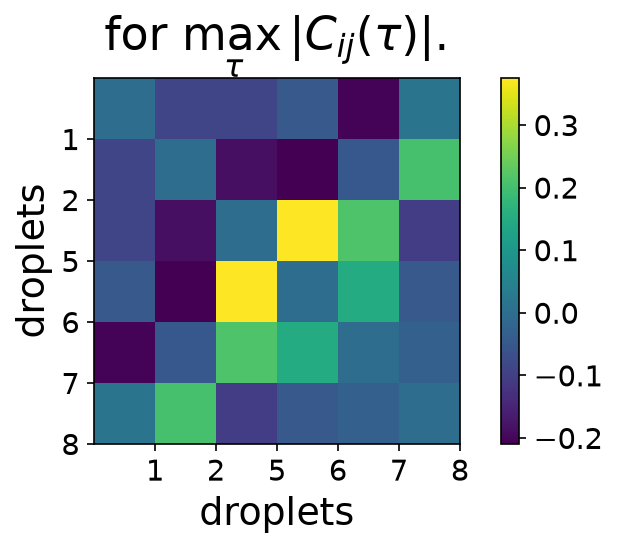

In [23]:
from analysis.plotting import plot_vacf_heatmap_btw_droplets
# from analysis.cross_analysis import compute_map
# m = compute_map(trajectories=trajectories,lagtime=lag_time)
plot_vacf_heatmap_btw_droplets(m,list(keys))

In [24]:
from analysis.types import PositionsDict
def compute_map(trajectories: PositionsDict,lagtime:int,
                taumax :None|NDArray[np.floating]= None,
                is_max:bool = True)->NDArray[np.floating]:
    
    """computes a heatmap between the droplets for tau = 0 or max Cij 

    Args:
        trajectories (PositionsDict): _description_
        lagtime (int): _description_
        is_max (bool, optional): _description_. Defaults to True.

    Returns:
        NDArray[np.floating]: _description_
    """
    nsize = len(trajectories.keys())
    m = np.zeros((nsize,nsize))
    taus = np.arange(lag_time) * 0.2
    
    for i,key1 in enumerate(trajectories.keys()):
        for j,key2 in enumerate(trajectories.keys()):
            if key1 != key2:
                vi = trajectories[key1]
                vj = trajectories[key2]
                cij ,_= compute_cross_vcaf(v1 = vi,v2= vj,lag_time=lagtime)
                if is_max:
                    m[i,j] = cij.max()
                    if taumax is not None:
                        # print(taus[cij == cij.max()] )
                        taumax[i,j] = taus[cij == cij.max()].squeeze()
                else:
                    m[i,j] = cij[0]
                    
    return m
            

In [25]:
tmax = np.zeros(shape=(6,6))
compute_map(trajectories=trajectories,taumax=tmax,lagtime= int(trajectories[2].shape[0] * 0.4))

array([[ 0.        , -0.07814272,  0.05706442,  0.1724194 ,  0.12690667,
         0.11837307],
       [ 0.19880249,  0.        ,  0.19215104,  0.03806863,  0.03522054,
         0.22481244],
       [ 0.12495964,  0.08078898,  0.        ,  0.39514009,  0.2367158 ,
        -0.08228864],
       [ 0.0192587 ,  0.04804521,  0.44809025,  0.        ,  0.20381668,
        -0.03617655],
       [ 0.02838418,  0.45004972,  0.214054  ,  0.14931458,  0.        ,
         0.25168239],
       [ 0.19451846,  0.20423086,  0.24192044,  0.11587988,  0.17417969,
         0.        ]])

In [26]:
import seaborn as sns 

In [27]:
tau_array = tmax/0.2
tau_array = tau_array.astype(dtype=int)

In [28]:
# tau_array.astype(dtype=int)
# for key in keys:
#     traj = trajectories[key]
#     plt.plot(traj[:,0],traj[:,1])

# for i in range(tau_array.shape[0]):
#     for j in range(tau_array.shape[1]):
#         plt.scatter()

In [29]:
tau_array

array([[   0, 1412, 1350, 1475, 1548, 1128],
       [1452,    0, 1572, 1560,  390,  876],
       [1420, 1524,    0,  192, 1020,    2],
       [ 608, 1345,  588,    0,  300,    3],
       [ 383, 1560,    0,    0,    0, 1548],
       [ 792,    0, 1440, 1548,  384,    0]])

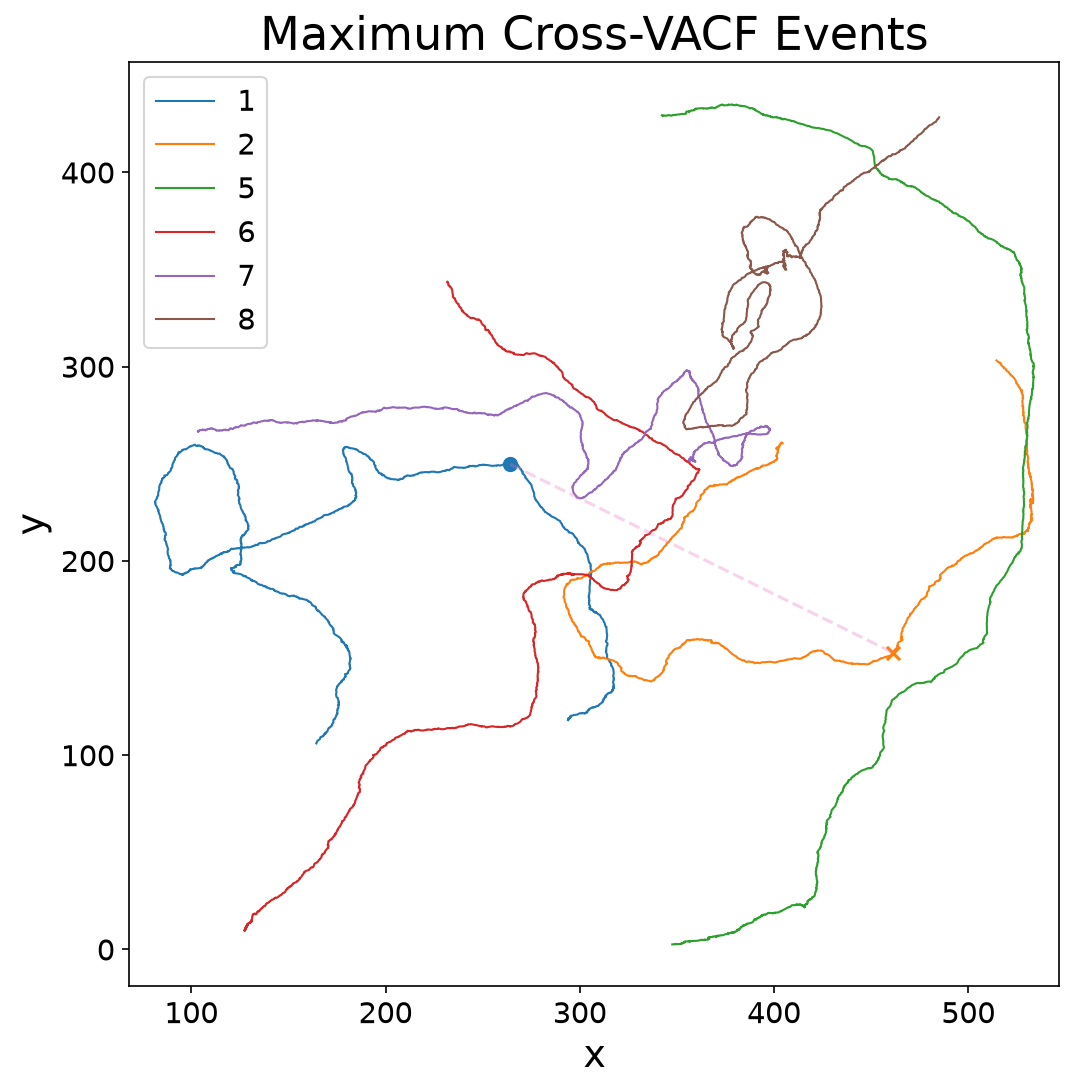

/tmp/ipykernel_2328/612455390.py:127: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


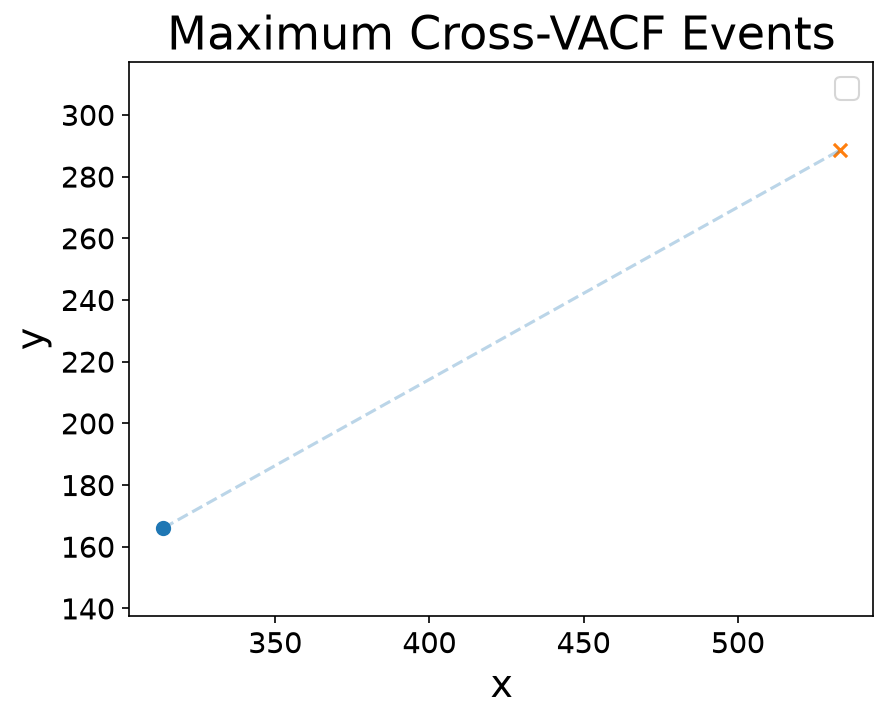

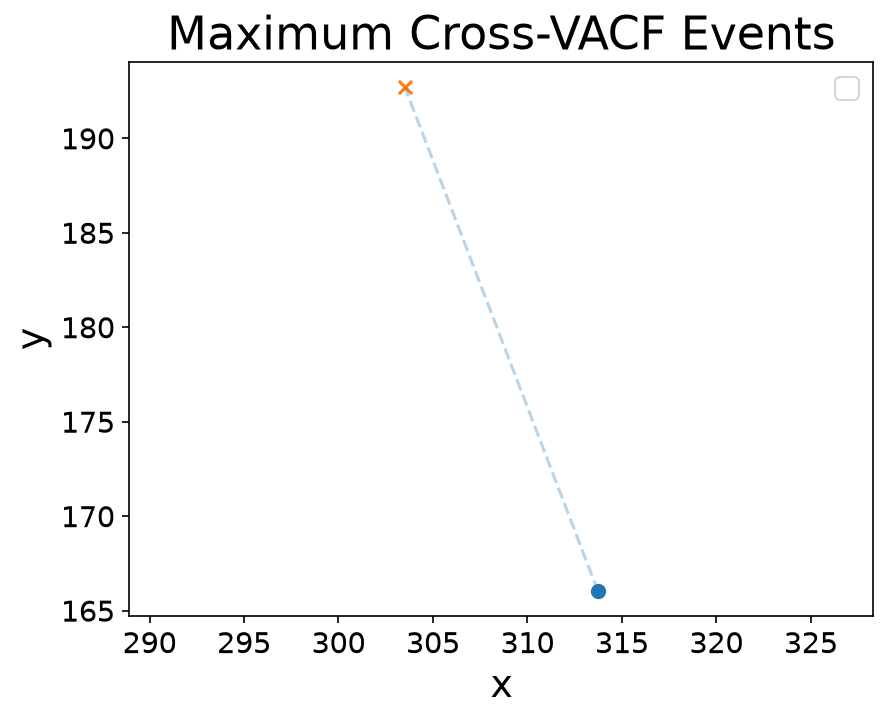

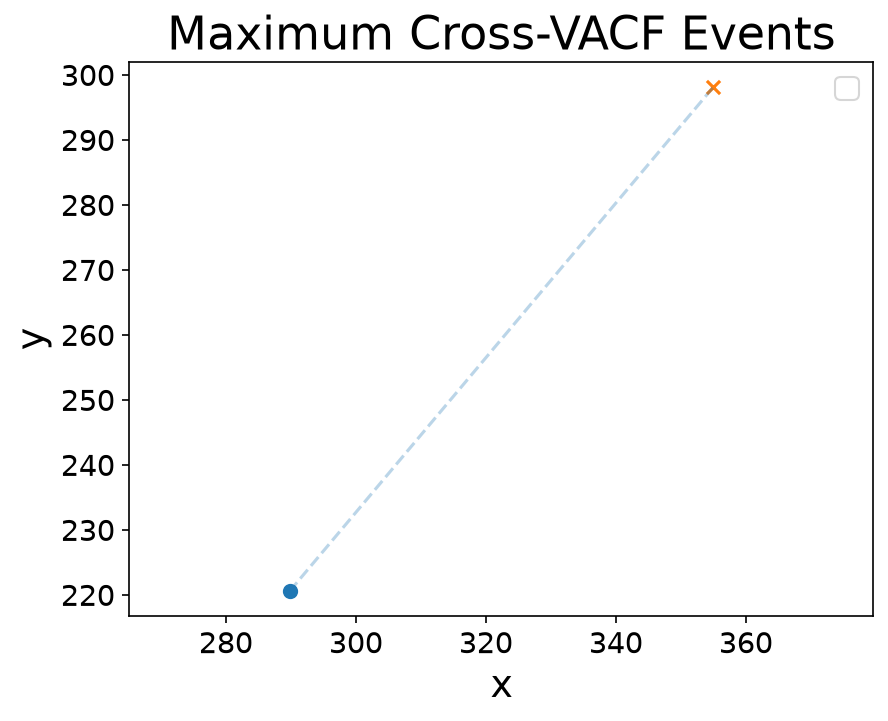

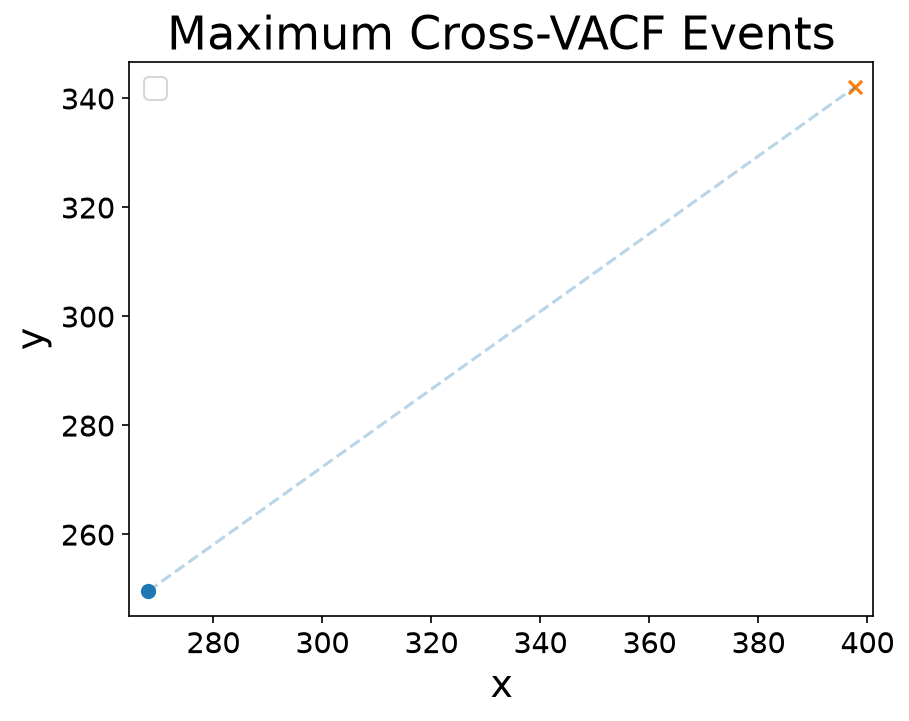

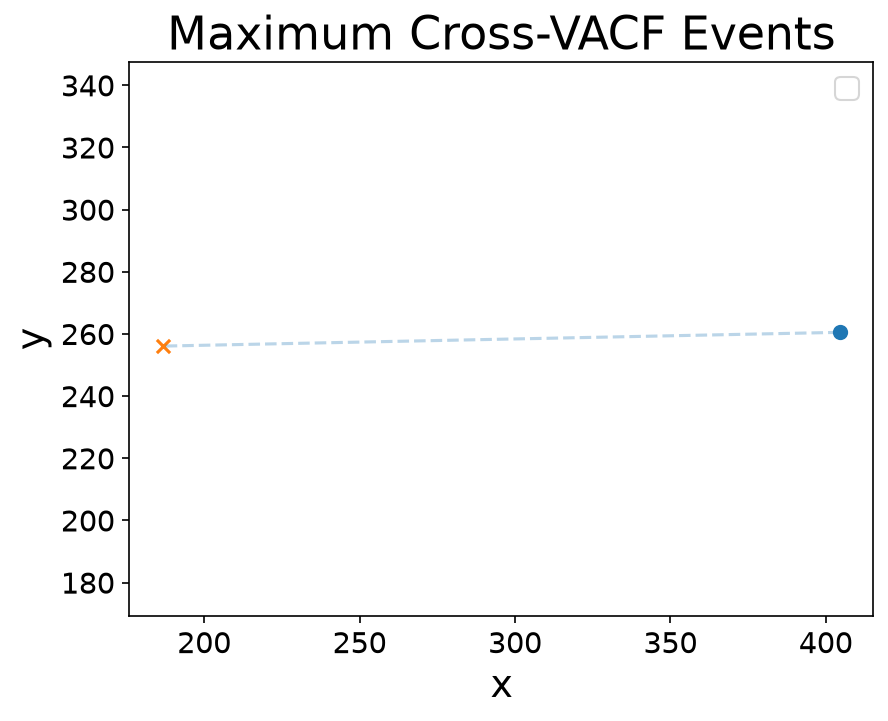

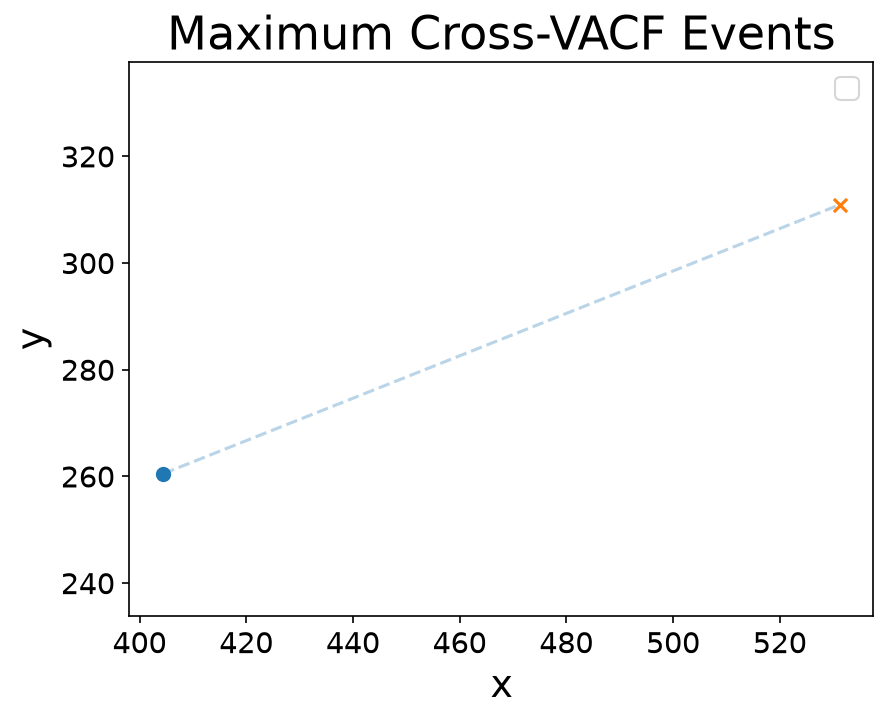

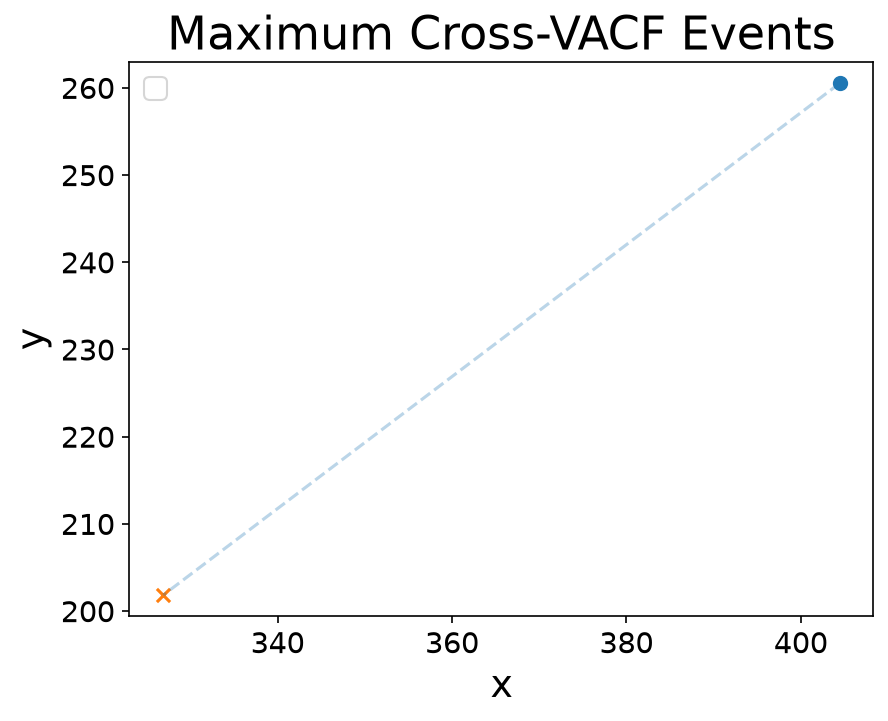

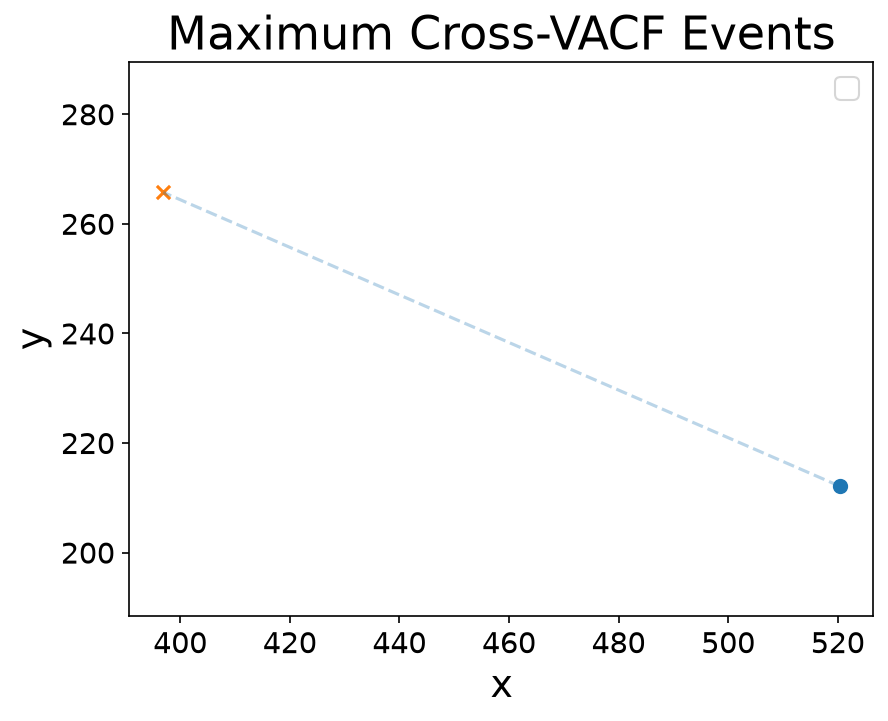

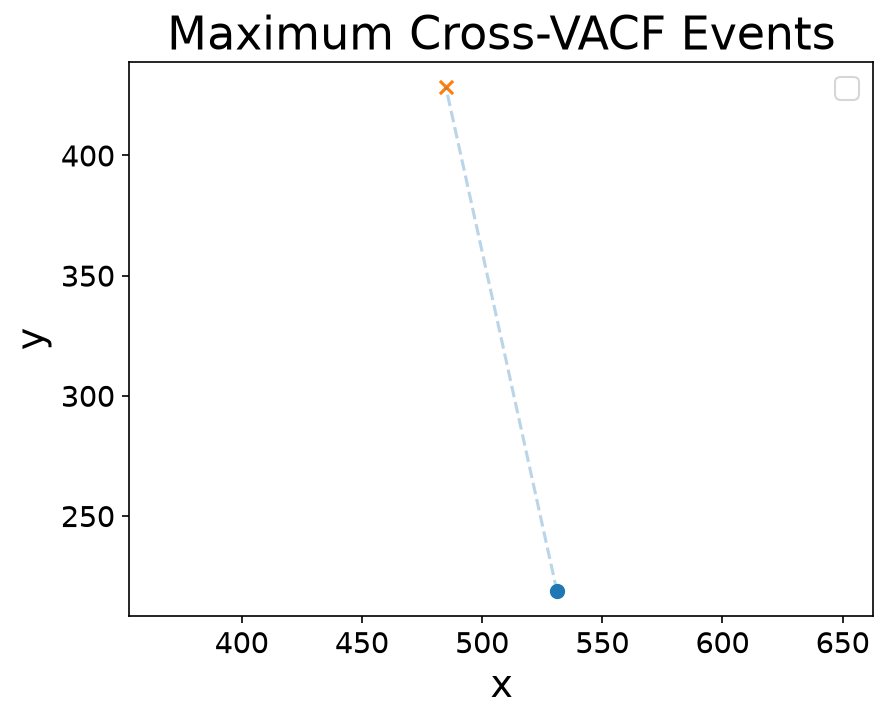

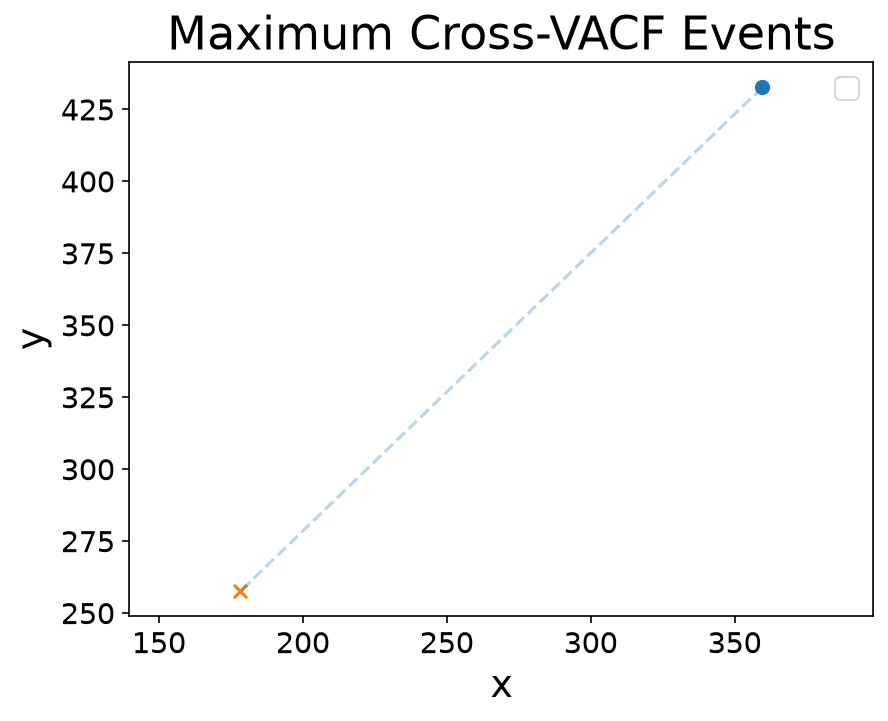

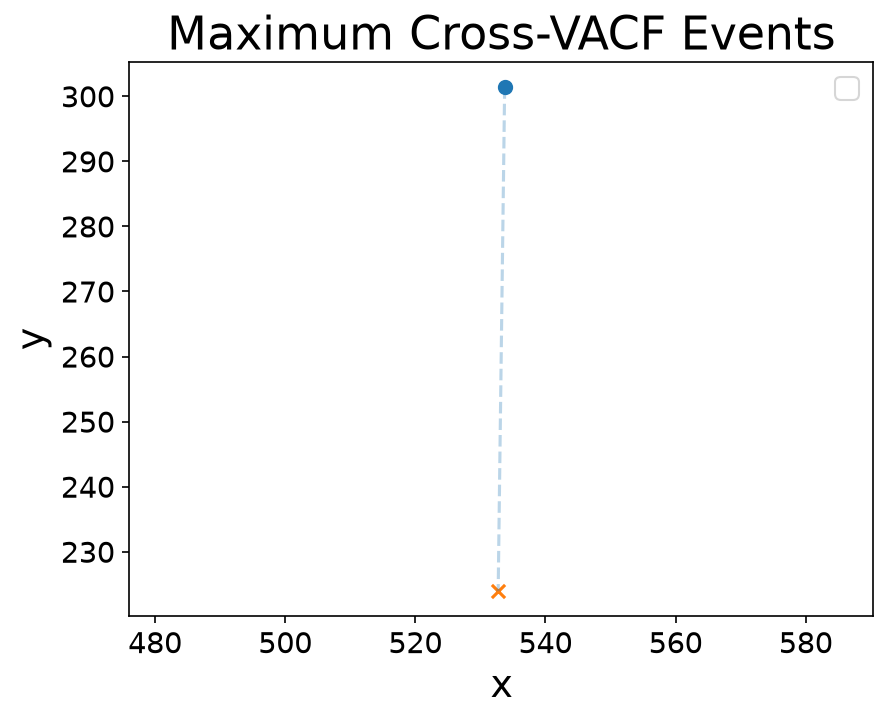

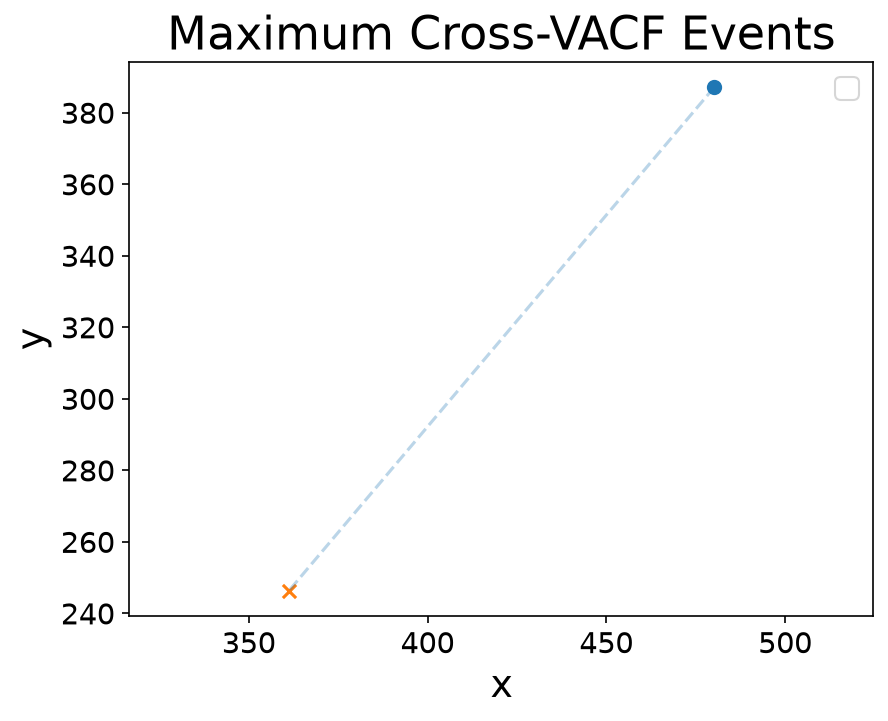

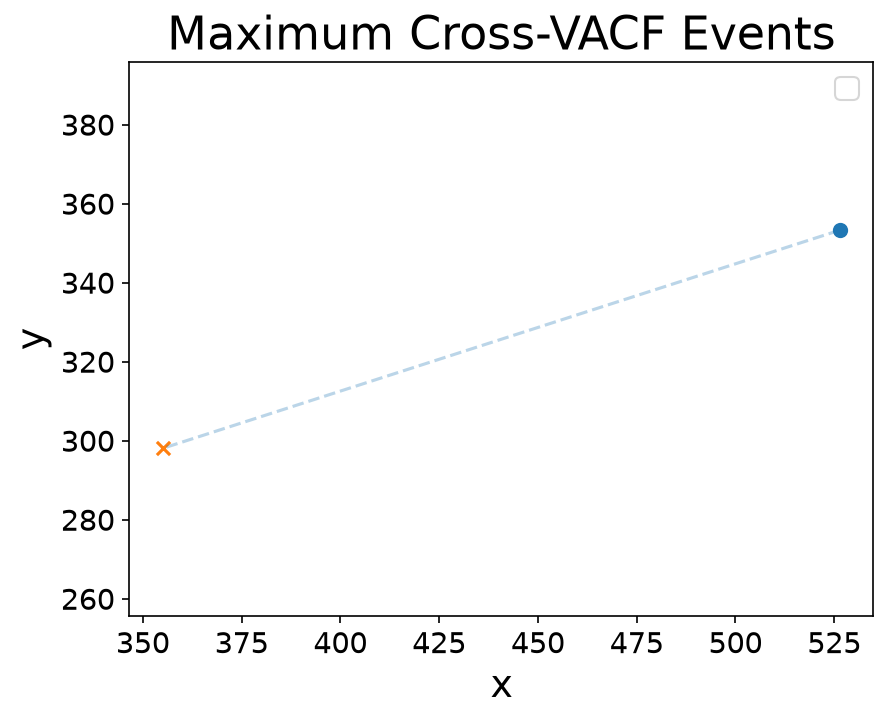

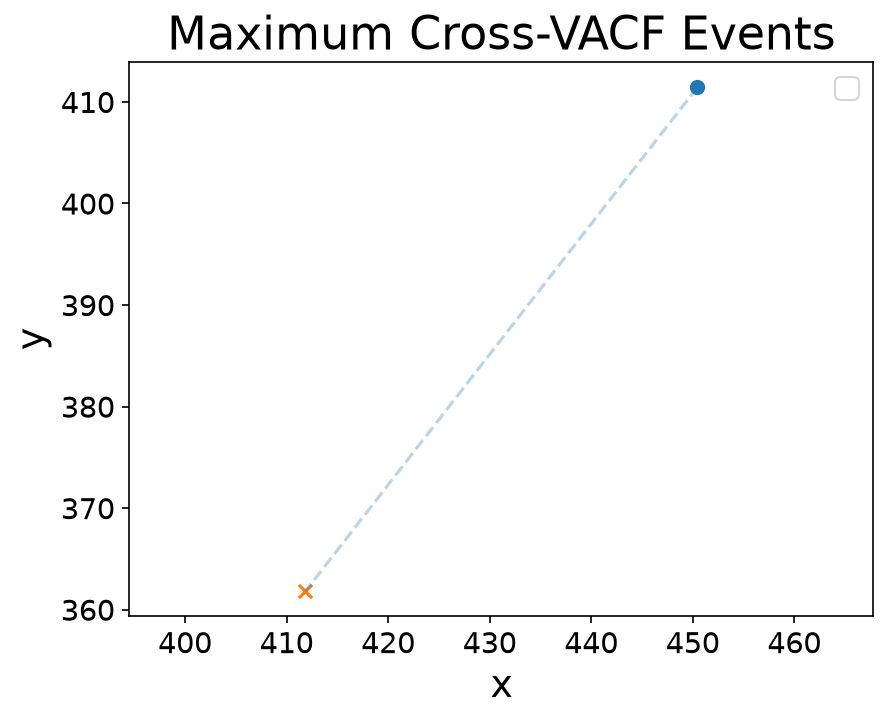

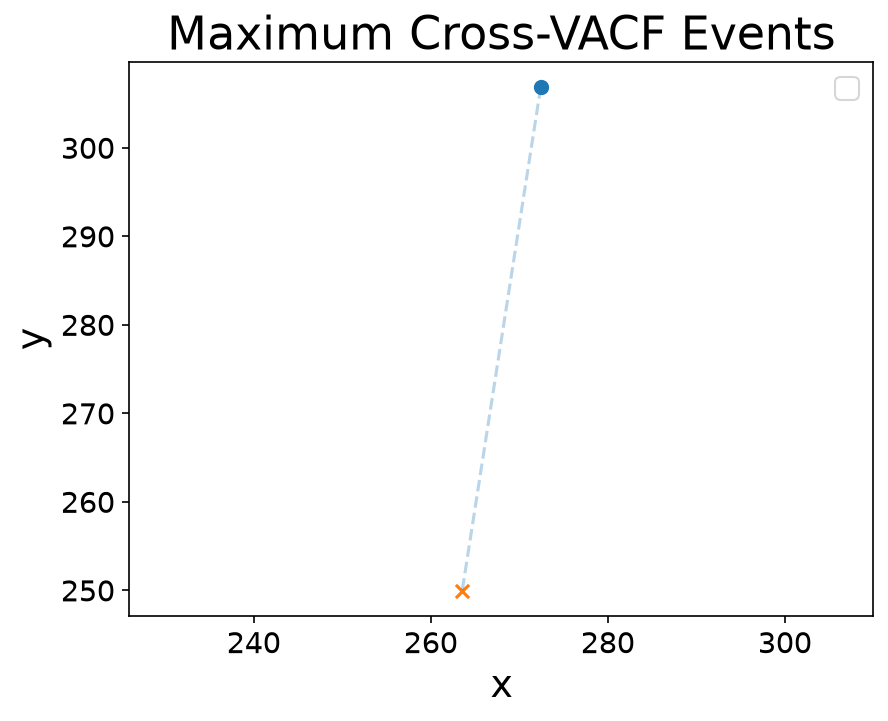

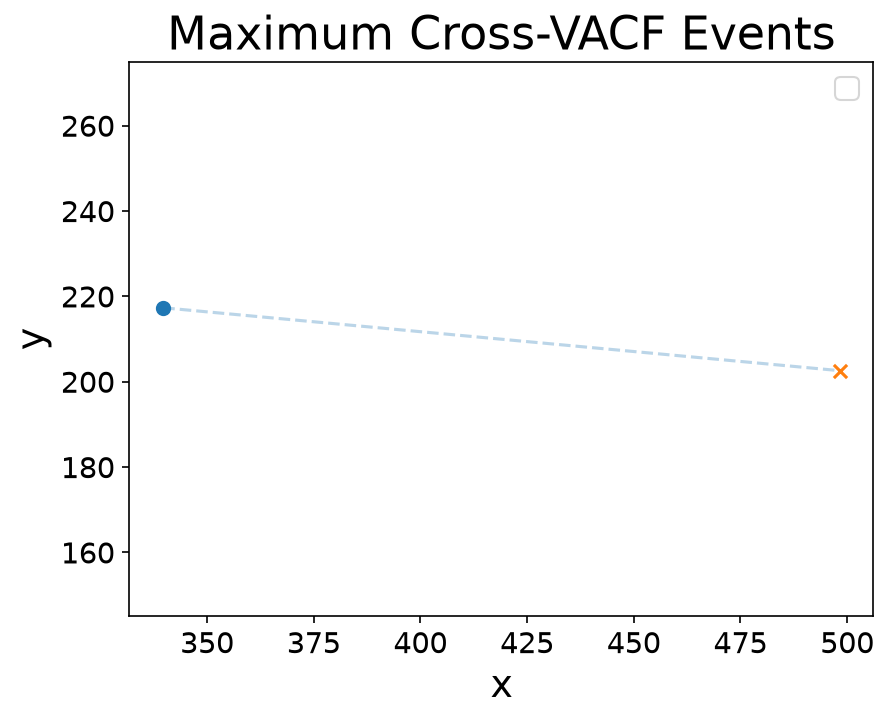

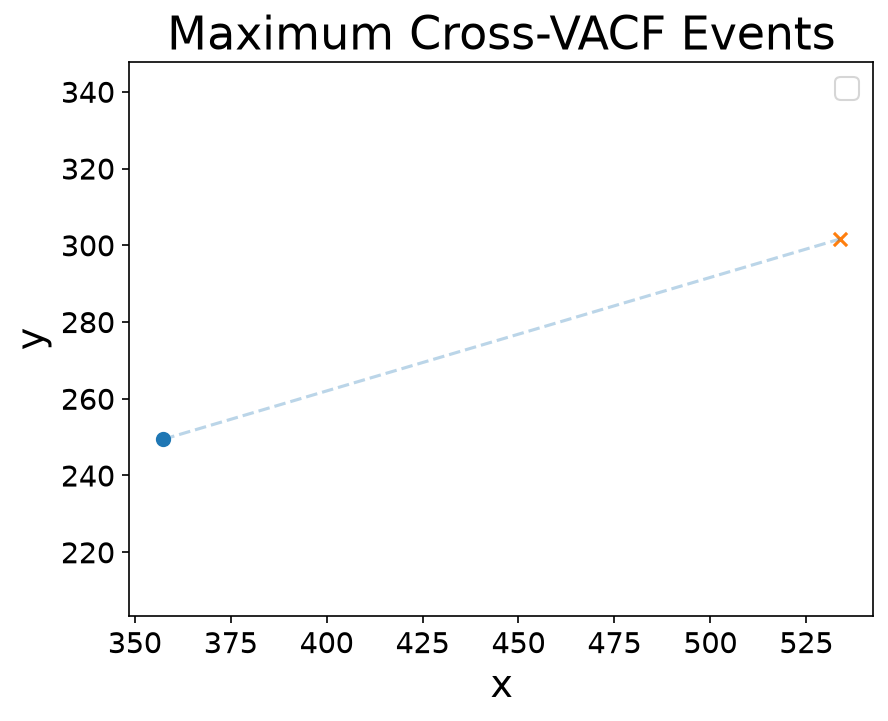

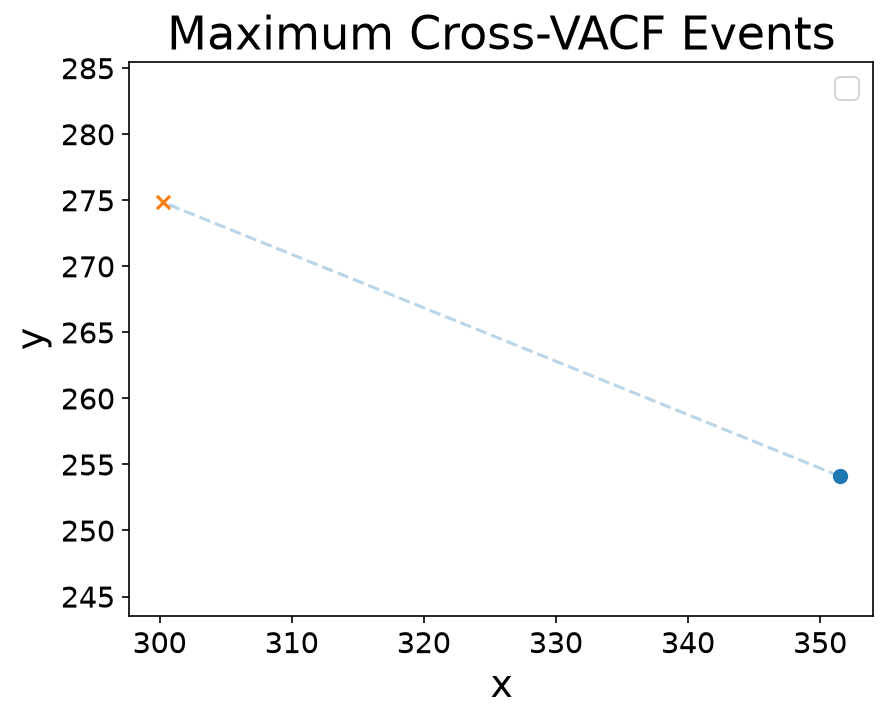

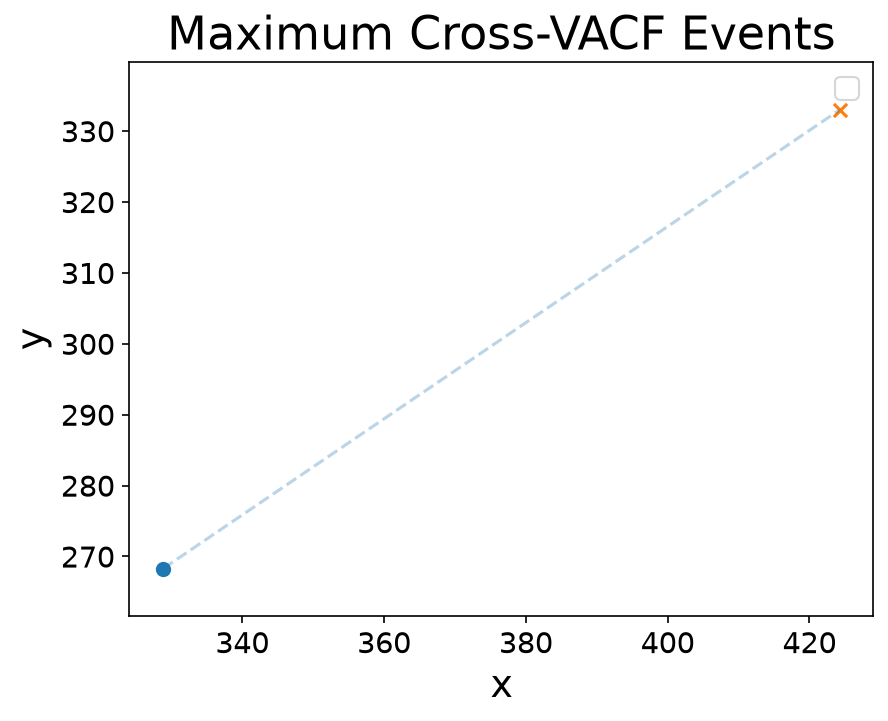

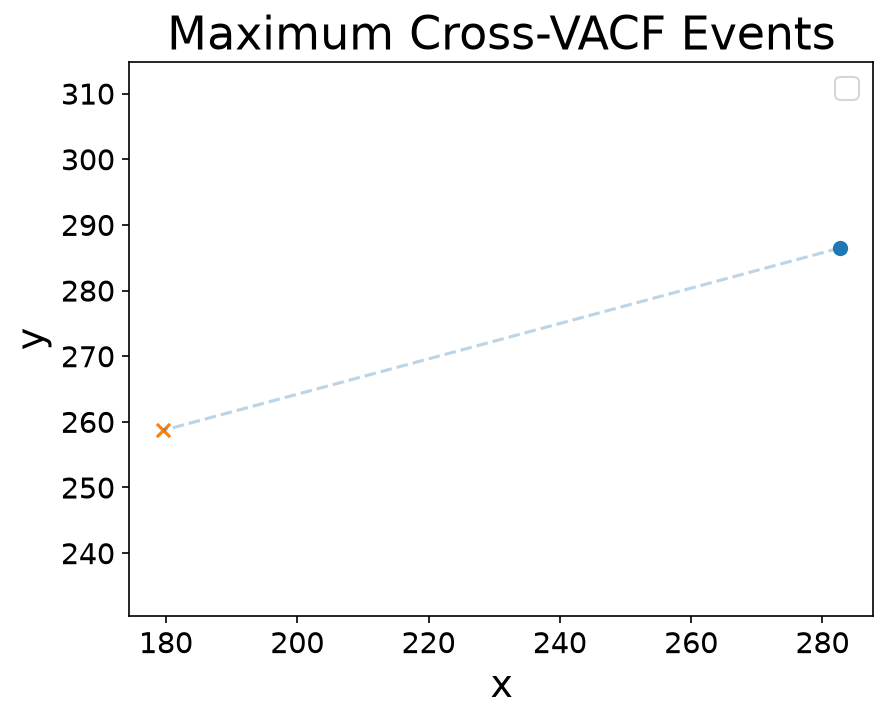

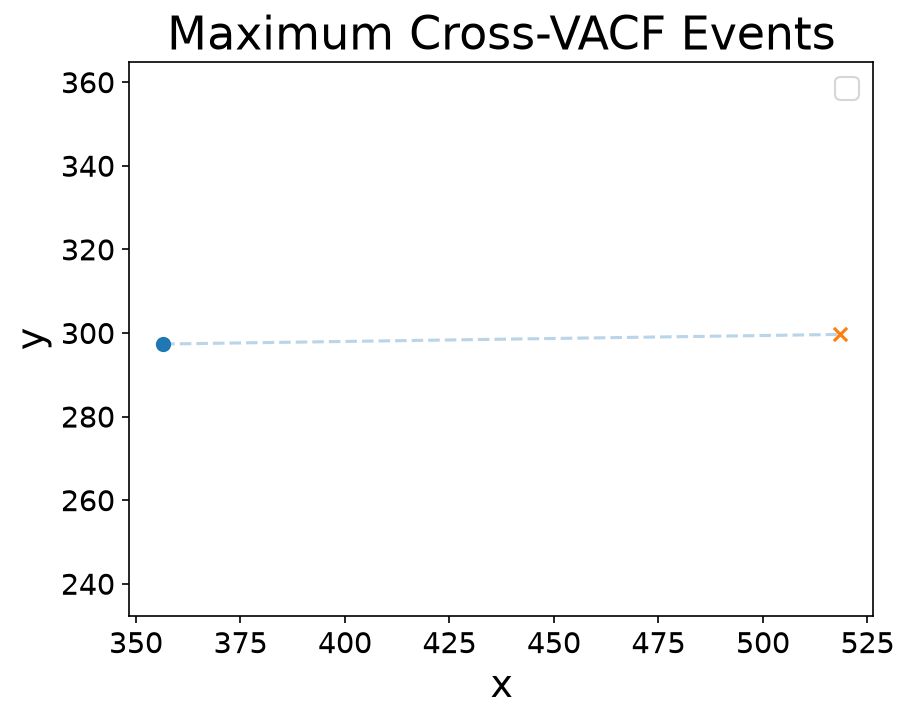

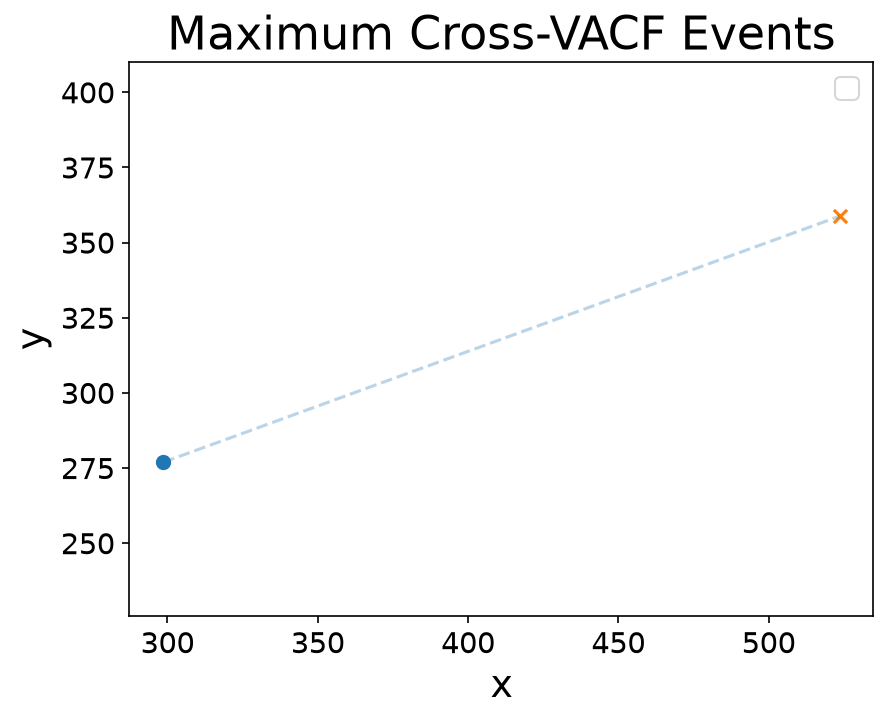

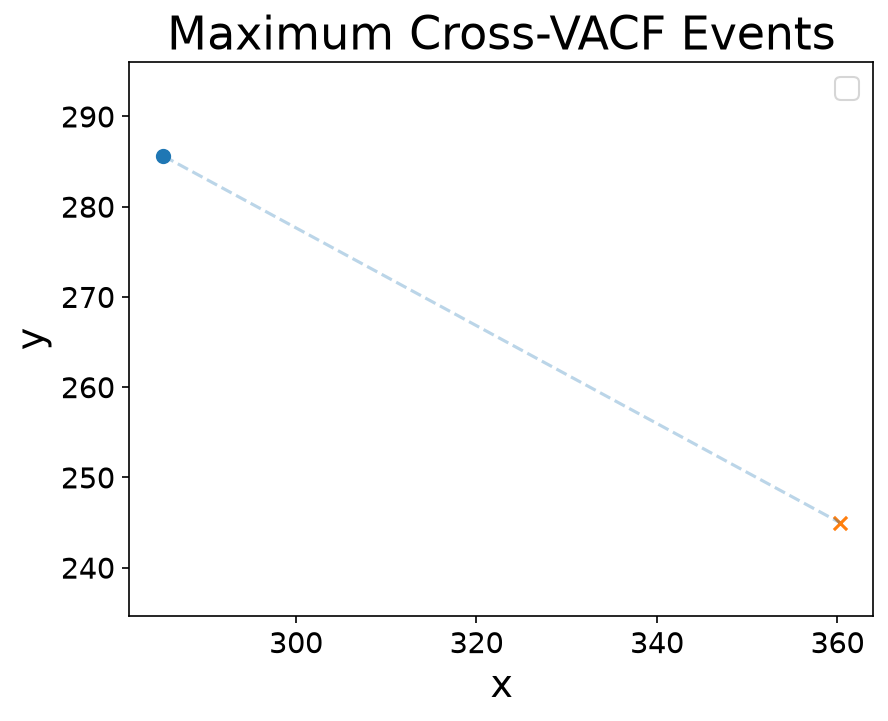

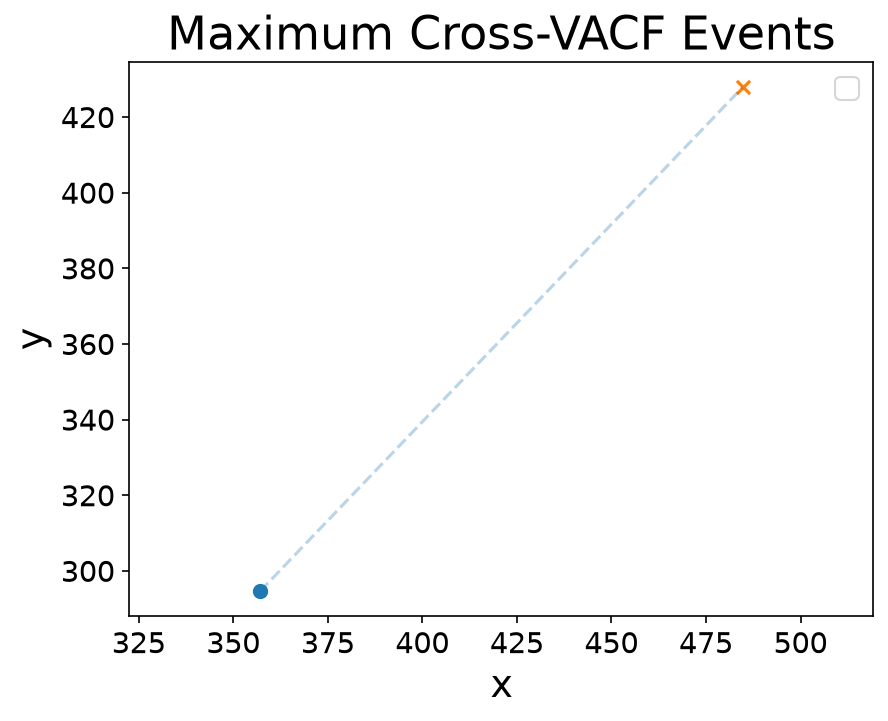

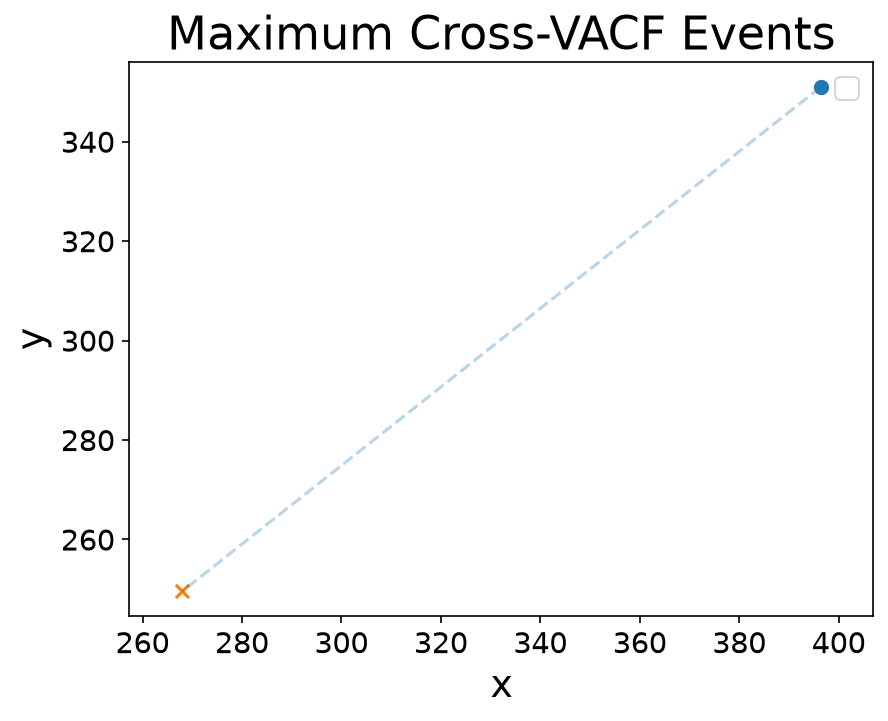

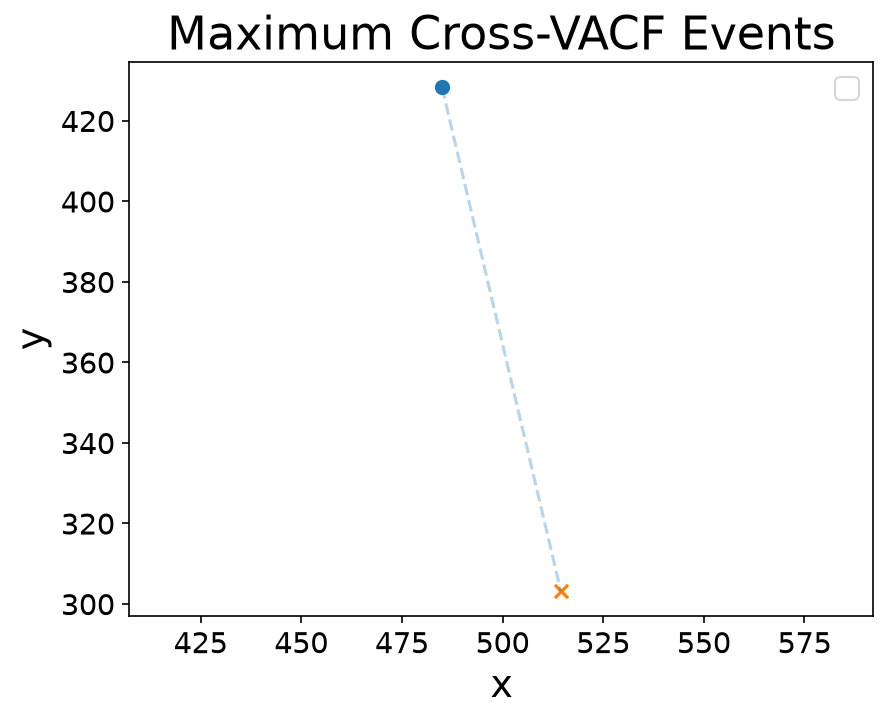

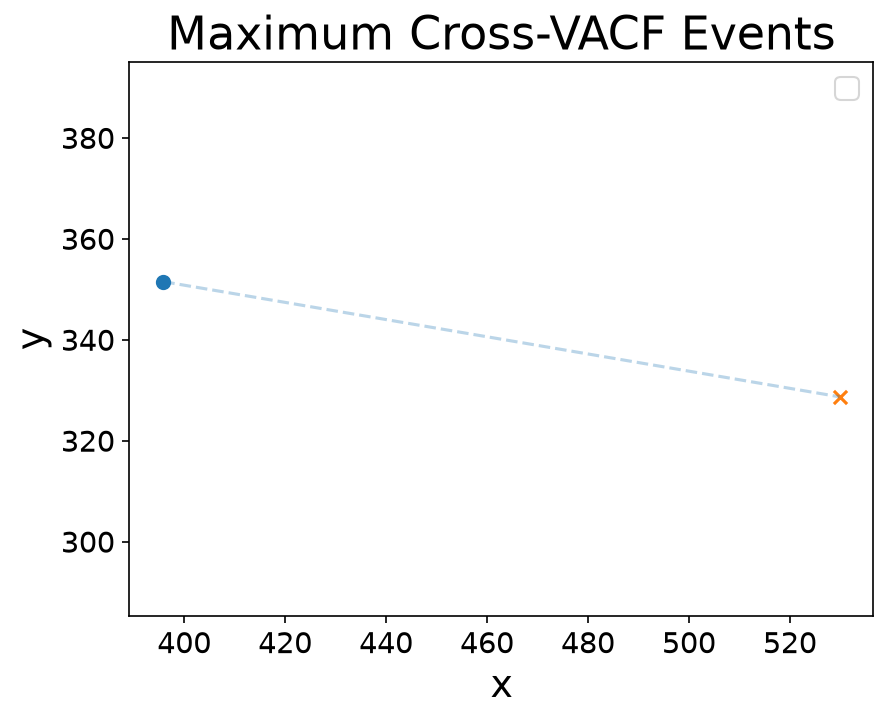

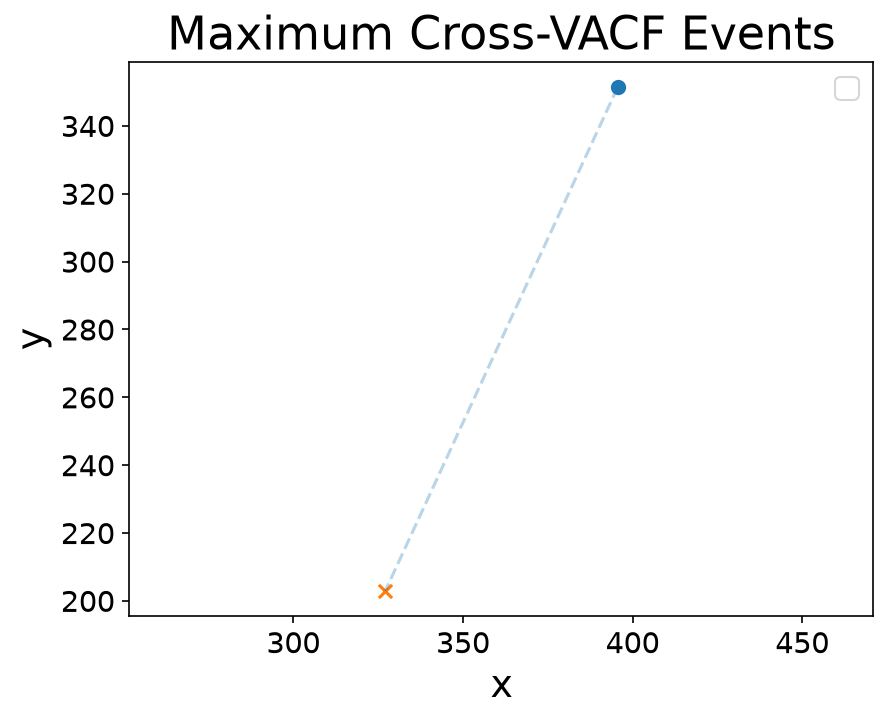

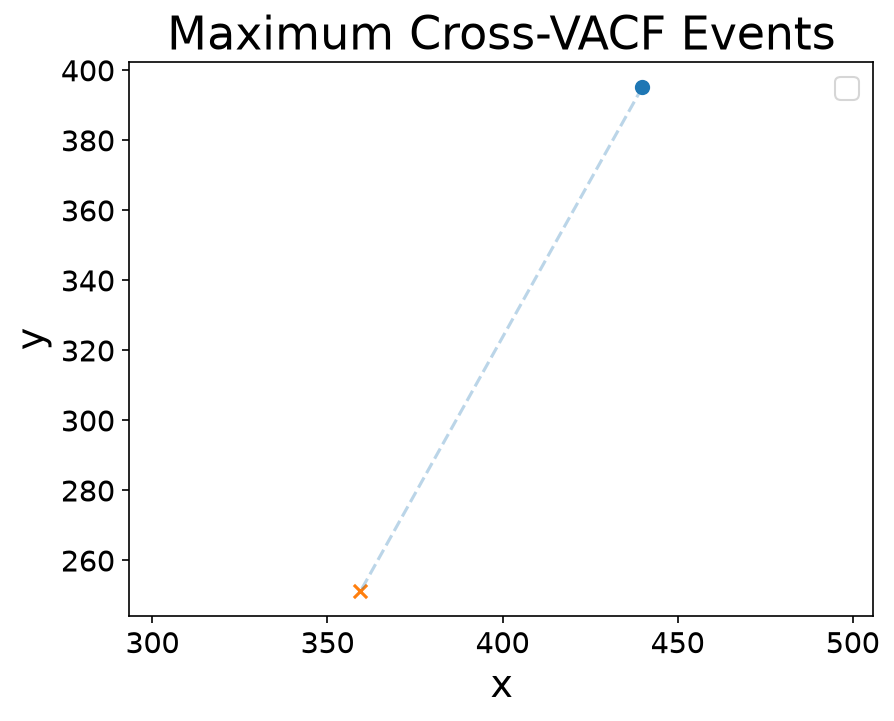

In [30]:
import numpy as np
import matplotlib.pyplot as plt


def compute_map(
    trajectories,
    lagtime,
):
    """
    Returns
    -------
    cmax : (N,N)
        Maximum cross-VACF value.

    taumax : (N,N)
        Lag where maximum occurs.

    tmax : (N,N)
        Starting frame that gives maximum contribution.
    """

    keys = list(trajectories.keys())
    n = len(keys)

    cmax = np.zeros((n, n))
    taumax = np.zeros((n, n), dtype=int)
    tmax = np.zeros((n, n), dtype=int)

    for i, key1 in enumerate(keys):
        for j, key2 in enumerate(keys):

            if i == j:
                continue

            v1 = trajectories[key1]
            v2 = trajectories[key2]

            cij, _ = compute_cross_vcaf(
                v1=v1,
                v2=v2,
                lag_time=lagtime
            )

            tau_star = np.argmax(cij)

            cmax[i, j] = cij[tau_star]
            taumax[i, j] = tau_star

            # Find frame producing largest contribution
            corr_t = np.sum(
                v1[:len(v1)-tau_star] *
                v2[tau_star:],
                axis=1
            )

            t_star = np.argmax(corr_t)

            tmax[i, j] = t_star

    return cmax, taumax, tmax

lagtime = int(0.4 * trajectories[2].shape[0])

cmax, taumax, tmax = compute_map(
    trajectories=trajectories,
    lagtime=lagtime
)

keys = list(trajectories.keys())

plt.figure(figsize=(8, 8))

for key in keys:
    traj = trajectories[key]

    plt.plot(
        traj[:, 0],
        traj[:, 1],
        lw=1,
        label=f"{key}"
    )
    
for i in range(len(keys)):
    for j in range(len(keys)):

        if i == j:
            continue

        tau = taumax[i, j]
        t = tmax[i, j]

        traj_i = trajectories[keys[i]]
        traj_j = trajectories[keys[j]]

        if t >= len(traj_i):
            continue

        if t + tau >= len(traj_j):
            continue

        xi, yi = traj_i[t]
        xj, yj = traj_j[t + tau]

        plt.scatter(
            xi,
            yi,
            s=40,
            marker="o"
        )

        plt.scatter(
            xj,
            yj,
            s=40,
            marker="x"
        )

        plt.plot(
            [xi, xj],
            [yi, yj],
            "--",
            alpha=0.3
        )
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title("Maximum Cross-VACF Events")
        plt.legend()
        plt.axis("equal")
        plt.show()

In [31]:
import numpy as np
import matplotlib.pyplot as plt

keys = list(trajectories.keys())

lagtime = int(0.4 * trajectories[keys[0]].shape[0])

n = len(keys)

cmax = np.zeros((n, n))
taumax = np.zeros((n, n), dtype=int)

for i, key1 in enumerate(keys):
    for j, key2 in enumerate(keys):

        if i == j:
            continue

        cij, _ = compute_cross_vcaf(
            v1=trajectories[key1],
            v2=trajectories[key2],
            lag_time=lagtime
        )

        tau_star = np.argmax(cij)

        cmax[i, j] = cij[tau_star]
        taumax[i, j] = tau_star

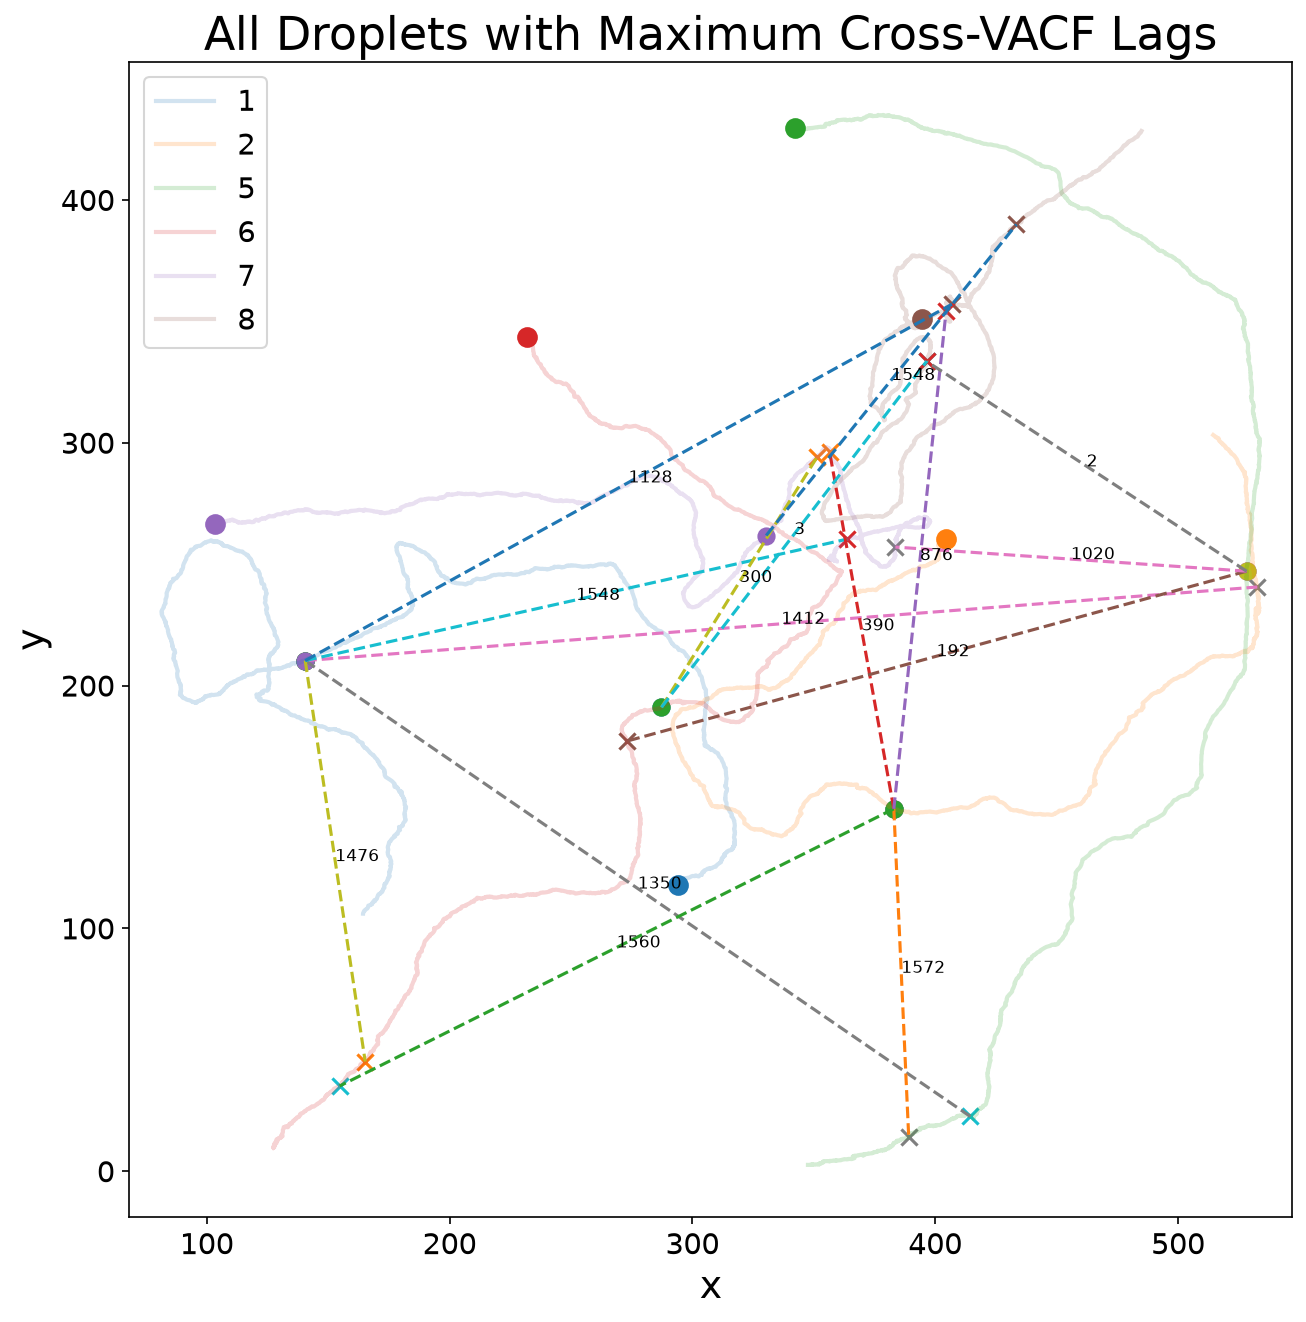

In [32]:
import numpy as np
import matplotlib.pyplot as plt

keys = list(trajectories.keys())
n = len(keys)

lagtime = int(0.4 * trajectories[keys[0]].shape[0])

cmax = np.zeros((n, n))
taumax = np.zeros((n, n), dtype=int)

# Compute max correlation lag matrix
for i, key1 in enumerate(keys):
    for j, key2 in enumerate(keys):

        if i == j:
            continue

        cij, _ = compute_cross_vcaf(
            v1=trajectories[key1],
            v2=trajectories[key2],
            lag_time=lagtime
        )

        tau_star = np.argmax(cij)

        cmax[i, j] = cij[tau_star]
        taumax[i, j] = tau_star

# ---------------------------------------------------
# Plot everything in one figure
# ---------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 10))

# Plot all trajectories
for key in keys:

    traj = trajectories[key]

    ax.plot(
        traj[:, 0],
        traj[:, 1],
        lw=2,
        label=f"{key}",
        alpha=0.2
    )

    # starting point
    ax.scatter(
        traj[0, 0],
        traj[0, 1],
        s=80,
        marker="o"
    )

# ---------------------------------------------------
# Draw pair connections at max-VACF lag
# ---------------------------------------------------

for i in range(n):
    for j in range(i + 1, n):

        tau = taumax[i, j]

        traj_i = trajectories[keys[i]]
        traj_j = trajectories[keys[j]]

        # choose midpoint frame for visualization
        t = min(
            len(traj_i) // 2,
            len(traj_j) - tau - 1
        )

        if t < 0:
            continue

        xi, yi = traj_i[t]
        xj, yj = traj_j[t + tau]

        # mark points
        ax.scatter(xi, yi, s=60, marker='o')
        ax.scatter(xj, yj, s=60, marker='x')

        # connect them
        ax.plot(
            [xi, xj],
            [yi, yj],
            '--',
            # alpha=0.4
        )

        # label lag
        ax.text(
            (xi + xj) / 2,
            (yi + yj) / 2,
            f"{tau}",
            fontsize=8
        )

ax.set_title("All Droplets with Maximum Cross-VACF Lags")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.axis("equal")
ax.legend()
# plt.show()

[[ 0.    -0.078  0.057  0.172  0.127  0.118]
 [ 0.199  0.     0.192  0.038  0.035  0.225]
 [ 0.125  0.081  0.     0.395  0.237 -0.082]
 [ 0.019  0.048  0.448  0.     0.204 -0.036]
 [ 0.028  0.45   0.214  0.149  0.     0.252]
 [ 0.195  0.204  0.242  0.116  0.174  0.   ]]


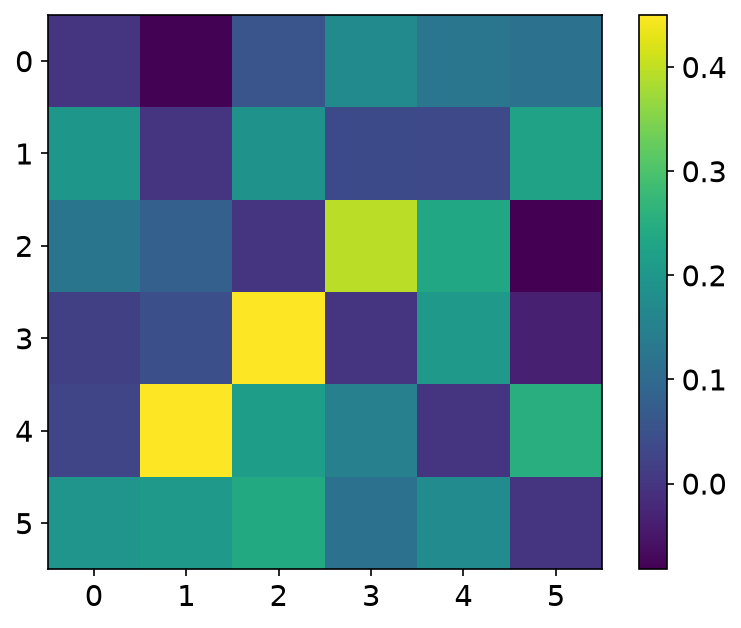

In [33]:
plt.imshow(cmax)
plt.colorbar()
print(np.round(cmax, 3))

In [34]:
cmax

array([[ 0.        , -0.07814272,  0.05706442,  0.1724194 ,  0.12690667,
         0.11837307],
       [ 0.19880249,  0.        ,  0.19215104,  0.03806863,  0.03522054,
         0.22481244],
       [ 0.12495964,  0.08078898,  0.        ,  0.39514009,  0.2367158 ,
        -0.08228864],
       [ 0.0192587 ,  0.04804521,  0.44809025,  0.        ,  0.20381668,
        -0.03617655],
       [ 0.02838418,  0.45004972,  0.214054  ,  0.14931458,  0.        ,
         0.25168239],
       [ 0.19451846,  0.20423086,  0.24192044,  0.11587988,  0.17417969,
         0.        ]])

(4, 1, np.float64(0.45004972415805206))
(3, 2, np.float64(0.44809024831622685))
(2, 3, np.float64(0.39514008540512924))
(4, 5, np.float64(0.25168238713786767))
(5, 2, np.float64(0.24192043654911974))
(2, 4, np.float64(0.2367158019317765))
(1, 5, np.float64(0.2248124394507681))
(4, 2, np.float64(0.21405399560125787))
(5, 1, np.float64(0.20423086289486903))
(3, 4, np.float64(0.20381667774582882))


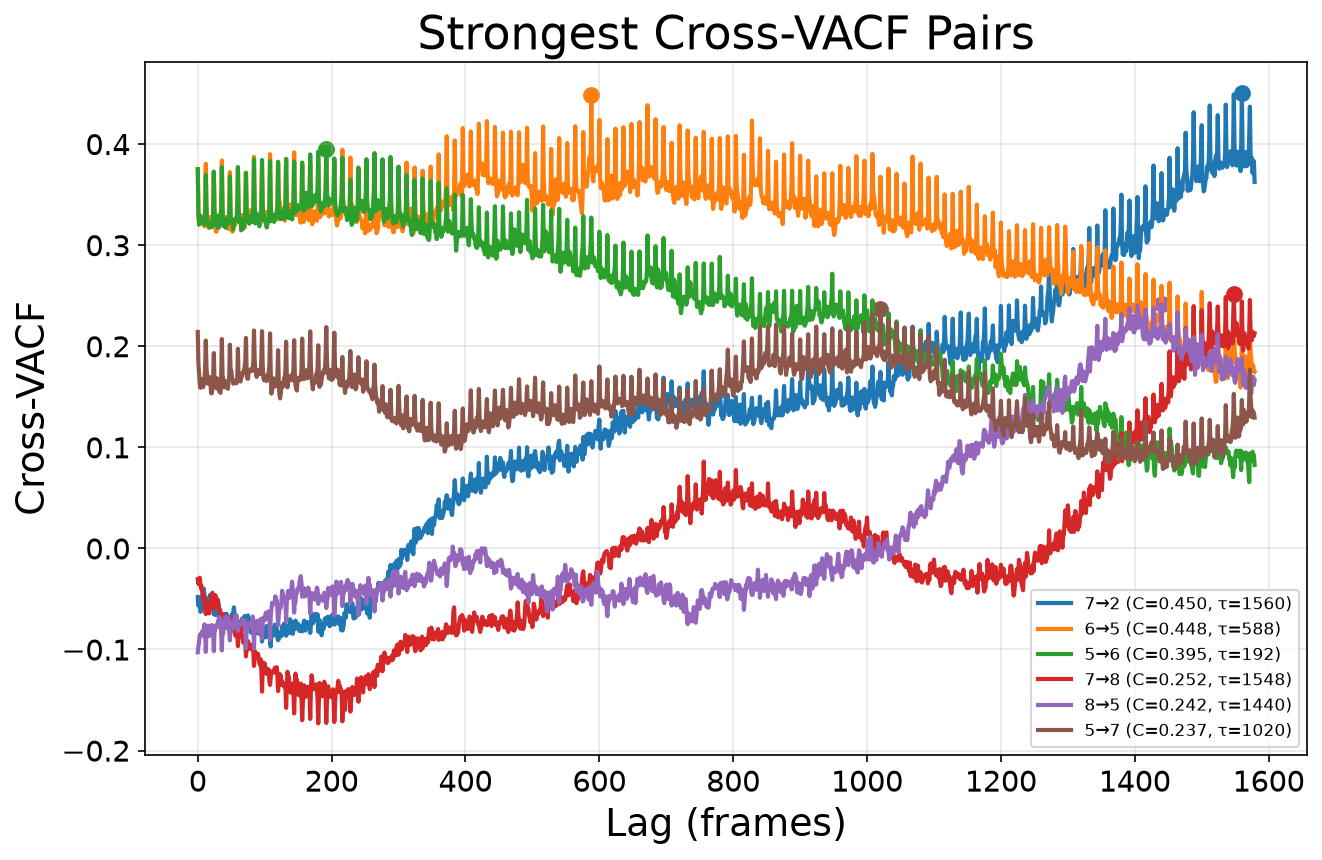

In [35]:
import numpy as np

n = cmax.shape[0]

pairs = []

for i in range(n):
    for j in range(n):
        if i != j:
            pairs.append((i, j, cmax[i, j]))

pairs = sorted(pairs, key=lambda x: x[2], reverse=True)

for p in pairs[:10]:
    print(p)
    
import matplotlib.pyplot as plt

top_n = 6

fig, ax = plt.subplots(figsize=(10, 6))

for i, j, _ in pairs[:top_n]:

    v1 = trajectories[keys[i]]
    v2 = trajectories[keys[j]]

    cij, _ = compute_cross_vcaf(
        v1=v1,
        v2=v2,
        lag_time=lagtime
    )

    tau_peak = np.argmax(cij)

    ax.plot(
        cij,
        lw=2,
        label=f"{keys[i]}→{keys[j]} "
              f"(C={cij[tau_peak]:.3f}, τ={tau_peak})"
    )

    ax.scatter(
        tau_peak,
        cij[tau_peak],
        s=50
    )

ax.set_xlabel("Lag (frames)")
ax.set_ylabel("Cross-VACF")
ax.set_title("Strongest Cross-VACF Pairs")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.show()

In [36]:
scores = []

for i in range(n):
    for j in range(n):

        if i == j:
            continue

        cij, _ = compute_cross_vcaf(
            v1=trajectories[keys[i]],
            v2=trajectories[keys[j]],
            lag_time=lagtime
        )

        peak = np.max(cij)
        tau_peak = np.argmax(cij)

        noise = np.std(cij)

        score = peak / noise if noise > 0 else np.nan

        scores.append(
            (keys[i], keys[j],
             peak,
             tau_peak,
             score)
        )

scores = sorted(
    scores,
    key=lambda x: x[-1],
    reverse=True
)

for s in scores[:10]:
    print(
        f"{s[0]}->{s[1]}  "
        f"Cmax={s[2]:.3f}  "
        f"tau={s[3]}  "
        f"score={s[4]:.2f}"
    )

6->5  Cmax=0.448  tau=588  score=8.30
5->7  Cmax=0.237  tau=1020  score=7.40
2->8  Cmax=0.225  tau=876  score=6.24
6->7  Cmax=0.204  tau=300  score=5.38
5->6  Cmax=0.395  tau=192  score=4.71
8->2  Cmax=0.204  tau=0  score=3.63
1->6  Cmax=0.172  tau=1476  score=3.62
7->2  Cmax=0.450  tau=1560  score=3.42
7->8  Cmax=0.252  tau=1548  score=2.77
8->5  Cmax=0.242  tau=1440  score=2.52


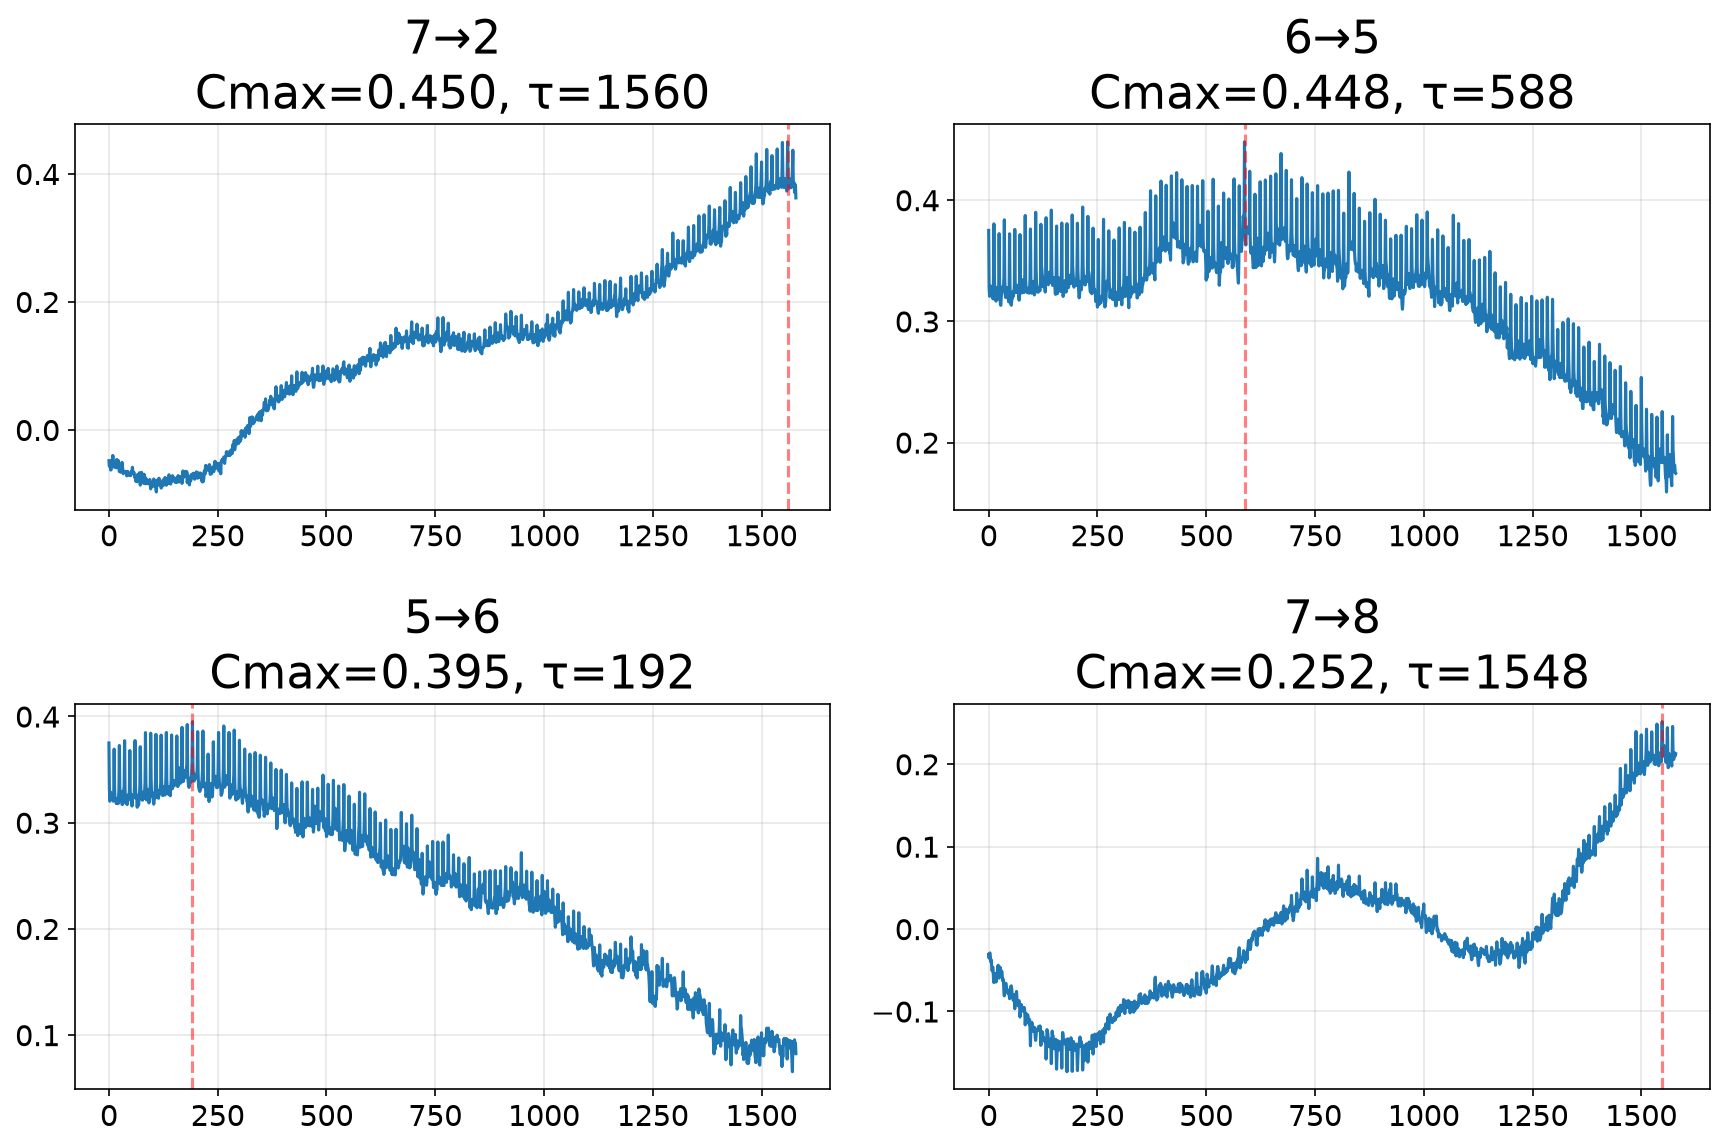

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, (i, j, _) in zip(axes, pairs[:4]):

    cij, _ = compute_cross_vcaf(
        v1=trajectories[keys[i]],
        v2=trajectories[keys[j]],
        lag_time=lagtime
    )

    tau_peak = np.argmax(cij)

    ax.plot(cij)

    ax.axvline(
        tau_peak,
        color='r',
        ls='--',
        alpha=0.5
    )

    ax.set_title(
        f"{keys[i]}→{keys[j]}\n"
        f"Cmax={cij[tau_peak]:.3f}, "
        f"τ={tau_peak}"
    )

    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
def compute_vacf(
    r: NDArray[np.floating],
    dt: float = 1.0,
    max_lag: int | None = None,
) -> NDArray[np.floating]:
    """
    Compute the velocity autocorrelation function for a single trajectory.

    Parameters
    ----------
    r : ndarray, shape (N, 2)
        Ordered (x, y) positions.
    dt : float
        Time step between consecutive frames.
    max_lag : int, optional
        Maximum lag (in frames) to compute. If None, uses all
        possible lags.

    Returns
    -------
    vacf : ndarray
        VACF values for lags τ = 0, ..., max_lag.

    Notes
    -----
    VACF(τ) = <v(t) · v(t+τ)>.
    """
    v = compute_velocity(r, dt)
    n = len(v)

    if max_lag is None:
        max_lag = n - 1
    else:
        max_lag = min(max_lag, n - 1)

    vacf = np.zeros(max_lag + 1)

    for tau in range(max_lag + 1):
        corr = (
            v[:n - tau, 0] * v[tau:, 0]
            + v[:n - tau, 1] * v[tau:, 1]
        )
        vacf[tau] = np.mean(corr)

    return vacf



def compute_map(trajectories: PositionsDict,lagtime:int,
                is_max:bool = True)->NDArray[np.floating]:
    """computes a heatmap between the droplets for tau = 0 or max Cij 

    Args:
        trajectories (PositionsDict): _description_
        lagtime (int): _description_
        is_max (bool, optional): _description_. Defaults to True.

    Returns:
        NDArray[np.floating]: _description_
    """
    nsize = len(trajectories.keys())
    m = np.zeros((nsize,nsize))

    for i,key1 in enumerate(trajectories.keys()):
        for j,key2 in enumerate(trajectories.keys()):
            if key1 != key2:
                vi = trajectories[key1]
                vj = trajectories[key2]
                cij,_ = compute_cross_vcaf(v1 = vi,v2= vj,lag_time=lagtime)
                # print(cij)
                if is_max:
                    m[i,j] = cij.max()
                else:
                    m[i,j] = cij[0]
            else:
                cii = compute_vacf(trajectories[key1],max_lag=lagtime, dt=0.2)
                m[i,j] = cii[0]
    return m


# def compute_eigen():
     
m = compute_map(trajectories=trajectories,lagtime= int(trajectories[2].shape[0] * 0.4),is_max=False)

In [42]:
m

array([[ 1.45581875, -0.0869224 , -0.08661441, -0.04684889, -0.20301079,
         0.01461525],
       [-0.0869224 ,  1.02227698, -0.1859669 , -0.2095869 , -0.04812895,
         0.20423086],
       [-0.08661441, -0.1859669 ,  1.45682395,  0.37505973,  0.214054  ,
        -0.10282607],
       [-0.04684889, -0.2095869 ,  0.37505973,  1.10887927,  0.14931458,
        -0.04571838],
       [-0.20301079, -0.04812895,  0.214054  ,  0.14931458,  0.78694191,
        -0.03065684],
       [ 0.01461525,  0.20423086, -0.10282607, -0.04571838, -0.03065684,
         1.02005478]])

In [ ]:


def compute_map(trajectories: PositionsDict,lagtime:int,
                is_max:bool = True)->NDArray[np.floating]:
    """computes a heatmap between the droplets for tau = 0 or max Cij 

    Args:
        trajectories (PositionsDict): _description_
        lagtime (int): _description_
        is_max (bool, optional): _description_. Defaults to True.

    Returns:
        NDArray[np.floating]: _description_
    """
    nsize = len(trajectories.keys())
    m = np.zeros((nsize,nsize))

    for i,key1 in enumerate(trajectories.keys()):
        for j,key2 in enumerate(trajectories.keys()):
            if key1 != key2:
                vi = trajectories[key1]
                vj = trajectories[key2]
                cij,_ = compute_cross_vcaf(v1 = vi,v2= vj,lag_time=lagtime)
                # print(cij)
                if is_max:
                    m[i,j] = cij.max()
                else:
                    m[i,j] = cij[0]
            else:
                cii = compute_vacf(trajectories[key1],max_lag=lagtime, dt=0.2)
                m[i,j] = cii[0]
    return m



In [ ]:
np.linalg.eig(m)


EigResult(eigenvalues=array([1.9189803 , 1.50182717, 1.09814814, 0.67815897, 0.74850146,
       0.90517959]), eigenvectors=array([[-0.24845897,  0.90864321,  0.21227529,  0.21896487, -0.1229107 ,
        -0.0672473 ],
       [-0.29408717, -0.31021057,  0.49104322, -0.00693076, -0.68964417,
        -0.31701984],
       [ 0.71860088,  0.12632324,  0.3768922 , -0.15256452,  0.14982512,
        -0.52904063],
       [ 0.48188269,  0.12985503,  0.12007391, -0.17414313, -0.49036432,
         0.68244121],
       [ 0.26154801, -0.16651499,  0.02894082,  0.94778286, -0.0481503 ,
         0.0491632 ],
       [-0.18648153, -0.13262649,  0.7459978 ,  0.01059424,  0.49402499,
         0.38333955]]))

In [ ]:
import numpy as np

# 1. Input your exact EigResult data
eigenvalues = np.array([1.9189803, 1.50182717, 1.09814814, 0.90517959, 0.74850146, 0.67815897])
eigenvectors = np.array([
    [-0.24845897,  0.90864321,  0.21227529,  0.21896487, -0.1229107 , -0.0672473 ],
    [-0.29408717, -0.31021057,  0.49104322, -0.00693076, -0.68964417, -0.31701984],
    [ 0.71860088,  0.12632324,  0.3768922 , -0.15256452,  0.14982512, -0.52904063],
    [ 0.48188269,  0.12985503,  0.12007391, -0.17414313, -0.49036432,  0.68244121],
    [ 0.26154801, -0.16651499,  0.02894082,  0.94778286, -0.0481503 ,  0.0491632 ],
    [-0.18648153, -0.13262649,  0.7459978 ,  0.01059424,  0.49402499,  0.38333955]
])

# 2. Assume you have your raw velocities: shape (num_frames, 6_droplets, 2_dimensions)
# For demonstration, we simulate random tracking data here
num_frames = 1000
raw_velocities = np.random.randn(num_frames, 6, 2) 

# 3. Project the velocities onto the dominant mode (Eigenvector 1) to find its amplitude over time
v1 = eigenvectors[:, 0]  # Shape: (6,) - Weights for the 6 droplets
mode1_amplitude = np.zeros((num_frames, 2))

for t in range(num_frames):
    # Vectorized dot product over the 6 droplets for both X and Y components
    mode1_amplitude[t, 0] = np.dot(raw_velocities[t, :, 0], v1) # X-amplitude
    mode1_amplitude[t, 1] = np.dot(raw_velocities[t, :, 1], v1) # Y-amplitude

# mode1_amplitude now tracks the pure, isolated collective swimming velocity of the swarm
print("Shape of extracted collective mode over time:", mode1_amplitude.shape)


Shape of extracted collective mode over time: (1000, 2)
